# Notebook 05 — RQ4: Temporal Stability and PSI Drift Analysis
## Evaluating AI/ML Credit Risk Models in U.S. Mortgage Lending

**Capstone:** QM640 Data Analytics Capstone — Walsh College  
**Author:** Saroj Kumar Nanda  
**Mentor:** Keya Choudhury Ganguli  
**Term:** Winter 2025  
**GitHub:** https://github.com/sarojnanda1/capstone

---

## Research Question 4
*How do AI/ML credit risk models perform across different economic periods, specifically pre- and post-COVID, and can PSI monitoring reliably detect model degradation before material prediction errors occur?*

**H₄₀:** PSI scores are not significantly predictive of subsequent model performance decline.  
**Time-series model:** AUCₜ₊₁ = β₀ + β₁PSIₜ + ε

---

## PSI Thresholds (SR 11-7 / Industry Standard)
| PSI Range | Status | Action |
|---|---|---|
| PSI < 0.10 | No significant change | Continue monitoring |
| 0.10 – 0.25 | Moderate shift | Monitor closely |
| PSI > 0.25 | Significant shift | Model review required |

---

## Notebook Structure
| Cell | Description |
|---|---|
| Cell 0 | Imports, Drive mount, seeds, paths |
| Cell 1 | Load Fannie Mae quarterly files (real or synthetic fallback) |
| Cell 2 | Feature engineering and pre/post-COVID split |
| Cell 3 | Train LR, XGBoost, FNN on pre-COVID data (2017–2019) |
| Cell 4 | Compute PSI and KL divergence per quarter (2021–2023) |
| Cell 5 | Time-series regression — H₄₀ evaluation |
| Cell 6 | Figures 21–24 |
| Cell 7 | Save RQ4 metrics for MRRS notebook |
| Cell 8 | Readiness verdict |

---

## Analysis Steps

1. Load Fannie Mae pre-COVID (2017–2019) and post-COVID (2021–2023) panels  
2. Train models on pre-COVID data  
3. Evaluate on post-COVID data quarter by quarter  
4. Compute PSI across rolling quarterly windows  
5. Compute KL divergence as a supplementary measure  
6. Time-series regression: AUCₜ₊₁ = β₀ + β₁PSIₜ + ε
7. Visualize drift patterns

## Important — Fannie Mae File Setup

Before running, run this diagnostic cell to check your filenames:
```python
import os
files = os.listdir('/content/drive/MyDrive/capstone/data/raw/fanniemae/')
for f in sorted(files):
    print(f)
```

## Outputs Produced
| File | Used by |
|---|---|
| `fig21_psi_trend.png` | Interim report §6 |
| `fig22_auc_trend.png` | Interim report §6 |
| `fig23_psi_vs_auc_scatter.png` | Interim report §6 |
| `fig24_kl_divergence.png` | Interim report §6 |
| `table4_quarterly_psi_auc.csv` | Interim report §6 |
| `rq4_metrics.json` | Notebook 06 (MRRS) |
| `rq4_psi_report.txt` | Documentation |

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
"""
CELL — List Raw Fannie Mae Files
--------------------------------
Lists all raw Fannie Mae data files stored in the project’s Google Drive
directory. This step verifies directory structure, confirms file
availability, and ensures that downstream ingestion cells reference the
correct filenames.

Purpose
-------
- Validate that the raw Fannie Mae directory exists and is accessible.
- Display all files in sorted order for reproducibility and auditability.
- Provide a quick visual check before loading or preprocessing data.
- Report the total number of files detected.

Notes
-----
- No files are read in this cell; only filenames are enumerated.
- Sorting ensures stable ordering across runs and environments.
"""

import os

FM_RAW_DIR = "/content/drive/MyDrive/capstone/data/raw/fanniemae/"

files = sorted(os.listdir(FM_RAW_DIR))

for f in files:
    print(f)

print(f"\nTotal files: {len(files)}")


2017Q1.csv
2017Q2.csv
2017Q3.csv
2017Q4.csv
2018Q1.csv
2018Q2.csv
2018Q3.csv
2018Q4.csv
2019Q1.csv
2019Q2.csv
2019Q3.csv
2019Q4.csv
2021Q1.csv
2021Q2.csv
2021Q3.csv
2021Q4.csv
2022Q1.csv
2022Q2.csv
2022Q3.csv
2022Q4.csv
2023Q1.csv
2023Q2.csv
2023Q3.csv
2023Q4.csv

Total files: 24


In [3]:
"""
CELL 0 — Environment Initialization, GPU Verification, Paths, Seeds, and Logging
-------------------------------------------------------------------------------
Initializes the complete runtime environment for the PSI (Population Stability
Index) analysis. This setup cell consolidates all imports, reproducibility
settings, directory paths, GPU/CPU configuration, and lightweight logging
utilities into a single deterministic initialization block.

Purpose
-------
- Import all scientific, statistical, ML, and visualization libraries.
- Set reproducible random seeds across NumPy, Python, and TensorFlow.
- Define canonical project paths for raw data, models, reports, and figures.
- Create required directories if missing.
- Configure TensorFlow GPU memory growth (if GPU available).
- Detect XGBoost GPU availability and set appropriate device parameters.
- Initialize global hyperparameters for FNN scoring (batch size, epochs).
- Provide logging utilities for audit‑ready report generation.

Outputs
-------
Global constants:
    RANDOM_STATE : int
    BASE, FM_RAW_DIR, MODEL_DIR, REPORT_DIR, FIG_DIR, REPORT_FILE : str
    TF_DEVICE : str
    XGB_DEVICE : str
    XGB_TREE_METHOD : str
    FNN_BATCH_SIZE : int
    FNN_EPOCHS : int

Logging utilities:
    log(msg)
    section(title)
    subsection(title)

Side effects:
    - Creates REPORT_DIR and FIG_DIR if they do not exist.
    - Prints GPU/CPU configuration summary.
    - Appends messages to `report_lines` for final PSI report assembly.

Notes
-----
- This cell must be executed before any PSI computation or model scoring.
- GPU availability affects FNN batch size and training/score performance.
- XGBoost GPU availability is tested using a minimal DMatrix.
"""

# ── Imports ───────────────────────────────────────────────────────────────────
import os
import json
import pickle
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import xgboost as xgb
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import roc_auc_score
import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE        = "/content/drive/MyDrive/capstone"
FM_RAW_DIR  = f"{BASE}/data/raw/fanniemae"
MODEL_DIR   = f"{BASE}/models"
REPORT_DIR  = f"{BASE}/reports"
FIG_DIR     = f"{BASE}/reports/figures"
REPORT_FILE = f"{REPORT_DIR}/rq4_psi_report.txt"

for d in [REPORT_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Logging Utilities ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
report_lines = []

def log(msg=""):
    """Append a message to the report log and print it."""
    print(msg)
    report_lines.append(str(msg))

def section(title):
    """Print a formatted section header and log it."""
    bar = "=" * 70
    log(); log(bar); log(f"  {title}"); log(bar)

def subsection(title):
    """Print a formatted subsection header and log it."""
    log(); log(f"── {title} " + "─" * max(0, 58 - len(title)))

# ── GPU Verification: TensorFlow ──────────────────────────────────────────────
section("CELL 0 · Environment Initialization and GPU Verification")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    TF_DEVICE = "/GPU:0"
    log(f"  ✓ TensorFlow GPU detected: {len(gpus)} device(s)")
    for g in gpus:
        log(f"    {g}")
    log("  ✓ Memory growth enabled")
else:
    TF_DEVICE = "/CPU:0"
    log("  ⚠  No GPU detected for TensorFlow — using CPU")

# ── GPU Verification: XGBoost ─────────────────────────────────────────────────
try:
    _dm = xgb.DMatrix(data=[[1,2],[3,4]], label=[0,1])
    xgb.train({"device": "cuda", "tree_method": "hist"},
              _dm, num_boost_round=1, verbose_eval=False)
    XGB_DEVICE = "cuda"
    XGB_TREE_METHOD = "hist"
    log("  ✓ XGBoost GPU (CUDA) available")
except Exception as e:
    XGB_DEVICE = "cpu"
    XGB_TREE_METHOD = "hist"
    log(f"  ⚠  XGBoost GPU not available — using CPU ({e})")

# ── Global FNN Hyperparameters ────────────────────────────────────────────────
FNN_BATCH_SIZE = 2048 if gpus else 256
FNN_EPOCHS     = 50   if gpus else 30
log(f"  FNN batch size : {FNN_BATCH_SIZE}")
log(f"  FNN max epochs : {FNN_EPOCHS}")

# ── Summary ───────────────────────────────────────────────────────────────────
log(f"\n  TensorFlow version : {tf.__version__}")
log(f"  XGBoost version    : {xgb.__version__}")
log(f"  TF device          : {TF_DEVICE}")
log(f"  XGBoost device     : {XGB_DEVICE}")
log("  ✓ Cell 0 complete")

log(f"  Fannie Mae raw dir: {FM_RAW_DIR}")
log(f"  Models dir        : {MODEL_DIR}")



  CELL 0 · Environment Initialization and GPU Verification
  ✓ TensorFlow GPU detected: 1 device(s)
    PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  ✓ Memory growth enabled
  ✓ XGBoost GPU (CUDA) available
  FNN batch size : 2048
  FNN max epochs : 50

  TensorFlow version : 2.19.0
  XGBoost version    : 3.2.0
  TF device          : /GPU:0
  XGBoost device     : cuda
  ✓ Cell 0 complete
  Fannie Mae raw dir: /content/drive/MyDrive/capstone/data/raw/fanniemae
  Models dir        : /content/drive/MyDrive/capstone/models


In [4]:
"""
CELL 1 — Load and Prepare Fannie Mae Performance Data
=====================================================
Loads, cleans, and prepares the Fannie Mae Single-Family Loan Performance
Dataset for pre-COVID vs. post-COVID analysis. The cell supports two modes:

1. Fast Path (default)
   Loads a cached parquet panel if available (~2 minutes). Recomputes the
   delinquency label if missing.

2. Slow Path
   Loads all 24 quarterly raw CSV files (~53 minutes). Extracts one
   origination-period snapshot per loan_id, imputes missing numeric values,
   derives delinquency labels, and caches the combined panel to parquet.

Dataset Overview
----------------
Fannie Mae Single-Family Loan Performance Dataset
Source      : https://capitalmarkets.fanniemae.com
Files       : /content/drive/MyDrive/capstone/data/raw/fanniemae/
Format      : Pipe-delimited CSV, 110 columns, no header row
Required    : 24 quarterly Performance files
Pre-COVID   : 2017Q1 – 2019Q4 (12 files)
Post-COVID  : 2021Q1 – 2023Q4 (12 files)
2020 excluded: COVID disruption confounds pre/post comparison

Key columns (confirmed from file inspection):
  Col  1 : loan_id
  Col  2 : reporting_period (MMYYYY)
  Col  8 : current_interest_rate
  Col  9 : current_upb
  Col 19 : original_ltv
  Col 22 : original_dti
  Col 23 : borrower_credit_score (FICO)
  Col 39 : current_delinquency_status
             Values: 0=current, 1=30-day, 2=60-day, 3+=90-day, XX=unknown

Strategy:
  Keep the first record per loan_id within each quarterly file to obtain
  one origination-period observation per loan.

Cache:
  Processed panel saved to parquet after first load. Subsequent sessions
  load from parquet (~2 min vs ~53 min).

Why the Slow Path Exists
------------------------
The slow path is intentionally preserved even though the parquet cache
enables fast loading. It exists for three governance-critical reasons:

1. Reproducibility (Audit Requirement)
   The parquet cache is a derived artifact. For full reproducibility,
   auditors, faculty reviewers, and future users must be able to rebuild
   the processed panel entirely from the original raw files.

2. Cache Invalidation and Schema Evolution
   Any change to selected columns, data types, imputation logic, quarter
   definitions, or updated Fannie Mae releases requires regenerating the
   parquet. The slow path guarantees a clean rebuild when the cache becomes
   stale.

3. Defensive Programming
   If the parquet cache becomes corrupted, partially written, deleted, or
   incompatible with future pandas/pyarrow versions, the slow path ensures
   the pipeline can still recover gracefully.

Checksum Mechanism
------------------
A checksum is computed from:
  - raw file names and sizes
  - USECOLS configuration

This checksum is stored alongside the parquet cache. If the checksum
changes (e.g., raw files updated, schema changed), the pipeline
automatically triggers the slow path to rebuild the dataset.

FORCE_REBUILD Flag
------------------
Setting FORCE_REBUILD = True bypasses the parquet cache entirely and
forces a full rebuild from raw files. This is useful for debugging,
schema changes, or validating reproducibility.

Processing Steps
----------------
  - Load cached parquet if present and checksum matches.
  - Otherwise load raw CSVs (slow path).
  - Convert delinquency_status to numeric; treat 'XX' as 0 (current).
  - Keep first record per loan_id within each quarterly file.
  - Concatenate all quarters into a single panel.
  - Median-impute missing numeric values.
  - Derive binary delinquency_label (1 = delinquent, 0 = current).
  - Save processed panel + checksum for future fast loading.

Outputs
-------
  - df_all         : pandas.DataFrame
  - PANEL_PATH     : str
  - SYNTHETIC_MODE : bool (always False for real Fannie Mae data)
"""

import time
import hashlib
import json
import os
import pandas as pd

# =============================================================================
# FALLBACK DEFINITIONS (if Cell 0 wasn't run)
# =============================================================================

if "section" not in globals():
    def section(title):
        print("\n" + "=" * 70)
        print(f"  {title}")
        print("=" * 70 + "\n")

if "log" not in globals():
    def log(msg):
        print(msg)

if "BASE" not in globals():
    BASE = "/content/drive/MyDrive/capstone"

if "FM_RAW_DIR" not in globals():
    FM_RAW_DIR = f"{BASE}/data/raw/fanniemae"

# =============================================================================
# RESTORED HEADER BLOCK
# =============================================================================

section("CELL 1 · Load and prepare Fannie Mae Performance data")

log("""
  Fannie Mae Single-Family Loan Performance Dataset
  Source      : https://capitalmarkets.fanniemae.com

  Files location : /content/drive/MyDrive/capstone/data/raw/fanniemae/
  File format    : Pipe-delimited CSV, 110 columns, no header row
  Files required : 24 quarterly Performance files
    Pre-COVID  : 2017Q1 – 2019Q4 (12 files)
    Post-COVID : 2021Q1 – 2023Q4 (12 files)
    2020 excluded: COVID disruption confounds pre/post comparison

  Key columns (confirmed from file inspection):
    Col  1 : loan_id
    Col  2 : reporting_period (MMYYYY)
    Col  8 : current_interest_rate
    Col  9 : current_upb
    Col 19 : original_ltv
    Col 22 : original_dti
    Col 23 : borrower_credit_score (FICO)
    Col 39 : current_delinquency_status
               Values: 0=current, 1=30-day, 2=60-day, 3+=90-day, XX=unknown

  Strategy: keep first record per loan_id within each quarterly file
  to get one origination-period observation per loan.

  Cache: processed panel saved to parquet after first load.
  Subsequent sessions load from parquet (~2 min vs ~53 min).
""")

# =============================================================================
# CONFIGURATION
# =============================================================================

FORCE_REBUILD = False

PANEL_PATH    = f"{BASE}/data/processed/fanniemae_panel.parquet"
CHECKSUM_PATH = PANEL_PATH.replace(".parquet", "_checksum.txt")

os.makedirs(f"{BASE}/data/processed", exist_ok=True)

# =============================================================================
# QUARTERS
# =============================================================================

PRE_COVID_QUARTERS  = [f"{y}Q{q}" for y in range(2017, 2020) for q in range(1, 5)]
POST_COVID_QUARTERS = [f"{y}Q{q}" for y in range(2021, 2024) for q in range(1, 5)]
ALL_QUARTERS        = PRE_COVID_QUARTERS + POST_COVID_QUARTERS

log(f"  Pre-COVID quarters  : {PRE_COVID_QUARTERS}")
log(f"  Post-COVID quarters : {POST_COVID_QUARTERS}")
log(f"  Total quarters      : {len(ALL_QUARTERS)}")

# =============================================================================
# COLUMN SPECIFICATION
# =============================================================================

USECOLS = [1, 2, 8, 9, 19, 22, 23, 39]

COL_NAMES = {
    1:  "loan_id",
    2:  "reporting_period",
    8:  "current_interest_rate",
    9:  "current_upb",
    19: "original_ltv",
    22: "original_dti",
    23: "borrower_credit_score",
    39: "delinquency_status",
}

DTYPES = {
    1:  str,
    2:  str,
    8:  "float32",
    9:  "float32",
    19: "float32",
    22: "float32",
    23: "float32",
    39: str,   # str — 'XX' (unknown) cannot be cast to float
}

# =============================================================================
# CHECKSUM
# =============================================================================

def compute_checksum():
    """
    Compute a checksum based on raw file names, sizes, and USECOLS.

    Used to detect whether the parquet cache is still valid. If any raw
    file changes in name or size, or if USECOLS is modified, the checksum
    will differ from the stored value and the slow path will be triggered.

    Returns
    -------
    str
        MD5 checksum string.
    """
    meta = {
        "files": sorted([
            (f, os.path.getsize(os.path.join(FM_RAW_DIR, f)))
            for f in os.listdir(FM_RAW_DIR)
            if f.endswith(".csv")
        ]),
        "usecols": USECOLS,
    }
    return hashlib.md5(json.dumps(meta, sort_keys=True).encode()).hexdigest()

# =============================================================================
# FAST PATH — load from cached parquet if available and checksum matches
# =============================================================================

cache_exists    = os.path.exists(PANEL_PATH)
checksum_exists = os.path.exists(CHECKSUM_PATH)

# _fast_path_taken controls whether the slow path runs below.
# Set to True here if the cache is valid; slow path executes only if False.
_fast_path_taken = False

if cache_exists and checksum_exists and not FORCE_REBUILD:
    cached_checksum  = open(CHECKSUM_PATH).read().strip()
    current_checksum = compute_checksum()

    if cached_checksum == current_checksum:
        log(f"\n  ✓ Cached panel found at {PANEL_PATH}")
        log("    Loading from parquet (much faster than raw files)...")

        t0      = time.time()
        df_all  = pd.read_parquet(PANEL_PATH)
        elapsed = time.time() - t0

        SYNTHETIC_MODE = False

        # Re-derive delinquency label if missing from an older cache
        if "delinquency_label" not in df_all.columns:
            df_all["delinquency_status"] = pd.to_numeric(
                df_all["delinquency_status"], errors="coerce"
            ).fillna(0)
            df_all["delinquency_label"] = (
                df_all["delinquency_status"] >= 1
            ).astype(int)
            log("    Delinquency label re-derived from cached data")

        log(f"\n    Panel loaded in  : {elapsed:.0f}s")
        log(f"    Rows             : {len(df_all):,}")
        log(f"    Columns          : {list(df_all.columns)}")
        log(f"    Quarters         : {sorted(df_all['quarter'].unique())}")

        mem_mb = df_all.memory_usage(deep=True).sum() / 1e6
        log(f"    Memory           : {mem_mb:.0f} MB")

        pos_rate = df_all["delinquency_label"].mean() * 100
        log(f"\n    Delinquency rate : {pos_rate:.3f}%")
        log(f"    Label = 1        : {df_all['delinquency_label'].sum():,}")
        log(f"    Label = 0        : {(df_all['delinquency_label'] == 0).sum():,}")

        log("\n  ✓ Cell 1 complete (loaded from cache)")

        _fast_path_taken = True   # <-- signals slow path to be skipped

# =============================================================================
# SLOW PATH — load from 24 raw CSV files (~53 minutes)
#
# Triggered when any of the following is true:
#   • No parquet cache exists (first run)
#   • No checksum file exists alongside the cache
#   • Checksum mismatch (raw files changed or USECOLS modified)
#   • FORCE_REBUILD = True (manual override)
# =============================================================================

if not _fast_path_taken:

    log("\n  ⚠ Cache missing, invalid, or rebuild forced — starting slow path")
    log("    This takes ~53 minutes on first run.\n")

    # ── Helper: load one quarterly file ──────────────────────────────────────

    def load_fm_performance(filepath, quarter_label):
        """
        Load one quarterly Fannie Mae Performance file.

        Reads the pipe-delimited CSV using only the columns defined in
        USECOLS/COL_NAMES/DTYPES. Converts delinquency_status to numeric
        (treating 'XX' as 0). Keeps the first record per loan_id to obtain
        one origination-period snapshot per loan.

        Parameters
        ----------
        filepath : str
            Path to the raw quarterly CSV file.
        quarter_label : str
            Quarter identifier string, e.g. '2017Q1'.

        Returns
        -------
        pandas.DataFrame or None
            DataFrame with one row per loan_id for the quarter,
            or None if the file fails to load.
        """
        try:
            df = pd.read_csv(
                filepath,
                sep="|",
                header=None,
                usecols=USECOLS,
                dtype=DTYPES,
                na_values=["", " ", "9999", "999", "NULL"],
                low_memory=False,
            )
            df.rename(columns=COL_NAMES, inplace=True)

            # Convert delinquency_status to numeric — 'XX' becomes NaN → 0
            df["delinquency_status"] = pd.to_numeric(
                df["delinquency_status"], errors="coerce"
            ).fillna(0)

            # Keep first record per loan (origination-period snapshot)
            df_first = (
                df.groupby("loan_id", sort=False)
                .first()
                .reset_index()
            )
            df_first["quarter"] = quarter_label

            log(f"    ✓ {quarter_label}: {len(df):>10,} monthly records → "
                f"{len(df_first):>8,} unique loans  "
                f"({os.path.basename(filepath)})")

            return df_first

        except Exception as e:
            log(f"    ✗ {quarter_label}: Failed — {e}")
            return None

    # ── Load all 24 quarterly files ───────────────────────────────────────────

    log(f"    Loading files from  : {FM_RAW_DIR}")
    log(f"    Columns loaded      : {len(USECOLS)} of 110")
    log("    (Progress updates after each file)\n")

    dfs           = []
    files_found   = []
    files_missing = []
    t0_total      = time.time()

    for quarter in ALL_QUARTERS:
        path = os.path.join(FM_RAW_DIR, f"{quarter}.csv")
        t0   = time.time()

        if os.path.exists(path) and os.path.getsize(path) > 1000:
            df = load_fm_performance(path, quarter)
            if df is not None and len(df) > 0:
                dfs.append(df)
                files_found.append(quarter)
                log(f"      ({time.time() - t0:.0f}s)")
            else:
                files_missing.append(quarter)
                log(f"    ⚠  {quarter}: loaded but empty")
        else:
            files_missing.append(quarter)
            log(f"    ✗  {quarter}: File not found — {path}")

    # ── Load summary ──────────────────────────────────────────────────────────

    total_elapsed = time.time() - t0_total
    log(f"\n    Load complete in      : {total_elapsed:.0f}s "
        f"({total_elapsed / 60:.1f} min)")
    log(f"    Successfully loaded   : {len(files_found)}/24 quarters")

    if files_missing:
        log(f"    Missing quarters      : {files_missing}")
        raise FileNotFoundError(
            f"{len(files_missing)} quarterly file(s) missing or empty: "
            f"{files_missing}"
        )

    if len(dfs) == 0:
        raise ValueError(
            "No data loaded. Check FM_RAW_DIR path and file format."
        )

    # ── Combine all quarters ──────────────────────────────────────────────────

    df_all         = pd.concat(dfs, ignore_index=True)
    SYNTHETIC_MODE = False

    log(f"\n    Combined panel        : {len(df_all):,} loan records")
    log(f"    Quarters present      : {sorted(df_all['quarter'].unique())}")

    mem_mb = df_all.memory_usage(deep=True).sum() / 1e6
    log(f"    Memory usage          : {mem_mb:.0f} MB")

    # ── Numeric imputation ────────────────────────────────────────────────────

    log("\n    Imputing missing values with column medians:")

    for col in ["borrower_credit_score", "original_dti",
                "original_ltv", "current_interest_rate", "current_upb"]:
        if col in df_all.columns:
            n_miss = df_all[col].isna().sum()
            med    = df_all[col].median()
            if n_miss > 0:
                df_all[col] = df_all[col].fillna(med)
                log(f"      {col:<35}: {n_miss:>8,} imputed "
                    f"(median = {med:.2f})")
            else:
                log(f"      {col:<35}: no missing values")

    # ── Delinquency label ─────────────────────────────────────────────────────
    # delinquency_status already converted to numeric in load_fm_performance.
    # 0 = current, 1+ = delinquent, NaN (from 'XX') treated as 0.

    df_all["delinquency_label"] = (
        df_all["delinquency_status"] >= 1
    ).astype(int)

    pos_rate   = df_all["delinquency_label"].mean() * 100
    delinq_vc  = df_all["delinquency_status"].value_counts().sort_index().head(6)

    log("\n    Delinquency label distribution:")
    for code, cnt in delinq_vc.items():
        meaning = ("current" if code == 0 else f"{int(code) * 30}-day delinquent")
        log(f"      Status {int(code):>2} ({meaning:<22}): "
            f"{cnt:>10,} ({cnt / len(df_all) * 100:.2f}%)")

    log(f"\n    Positive rate (delinquent) : {pos_rate:.3f}%")
    log(f"    Label = 1 (delinquent)     : {df_all['delinquency_label'].sum():,}")
    log(f"    Label = 0 (current)        : {(df_all['delinquency_label'] == 0).sum():,}")

    if pos_rate < 0.01 or pos_rate > 50:
        log("    ⚠  Unusual positive rate — check delinquency column")
    else:
        log("    ✓  Positive rate within expected range for mortgage data")

    # ── Save to parquet cache + checksum ──────────────────────────────────────

    log("\n    Saving processed panel to parquet cache...")
    log("    (Future sessions will load in ~2 min instead of ~53 min)")

    t0 = time.time()
    df_all.to_parquet(PANEL_PATH, index=False)

    with open(CHECKSUM_PATH, "w") as f:
        f.write(compute_checksum())

    cache_size_mb = os.path.getsize(PANEL_PATH) / 1e6
    log(f"    → Cached   : {PANEL_PATH}")
    log(f"    → Checksum : {CHECKSUM_PATH}")
    log(f"    → Size     : {cache_size_mb:.0f} MB")
    log(f"    → Saved in : {time.time() - t0:.0f}s")

    log(f"\n  ✓ Cell 1 complete — {len(df_all):,} records ready for analysis")


  CELL 1 · Load and prepare Fannie Mae Performance data

  Fannie Mae Single-Family Loan Performance Dataset
  Source      : https://capitalmarkets.fanniemae.com

  Files location : /content/drive/MyDrive/capstone/data/raw/fanniemae/
  File format    : Pipe-delimited CSV, 110 columns, no header row
  Files required : 24 quarterly Performance files
    Pre-COVID  : 2017Q1 – 2019Q4 (12 files)
    Post-COVID : 2021Q1 – 2023Q4 (12 files)
    2020 excluded: COVID disruption confounds pre/post comparison

  Key columns (confirmed from file inspection):
    Col  1 : loan_id
    Col  2 : reporting_period (MMYYYY)
    Col  8 : current_interest_rate
    Col  9 : current_upb
    Col 19 : original_ltv
    Col 22 : original_dti
    Col 23 : borrower_credit_score (FICO)
    Col 39 : current_delinquency_status
               Values: 0=current, 1=30-day, 2=60-day, 3+=90-day, XX=unknown

  Strategy: keep first record per loan_id within each quarterly file
  to get one origination-period observation pe

In [5]:
"""
CELL 2 — Feature Engineering and Pre/Post‑COVID Split
=====================================================

Purpose
-------
Prepare the Fannie Mae Performance dataset for RQ4 modeling by:
1. Aligning column names from Cell 1 (current_* → original_*).
2. Cleaning and imputing numeric features using median imputation.
3. Creating engineered features (log_upb).
4. One‑hot encoding loan_purpose.
5. Constructing the final feature matrix for modeling.
6. Splitting the dataset into pre‑COVID (2017–2019) and post‑COVID (2021–2023).
7. Scaling features using StandardScaler (fit on pre‑COVID only).

Inputs
------
df_all : pandas.DataFrame
    Full panel dataset produced by Cell 1, containing:
    - loan_id
    - borrower_credit_score
    - original_dti / current_dti
    - original_ltv / current_ltv
    - original_interest_rate / current_interest_rate
    - current_upb
    - loan_purpose
    - delinquency_label
    - quarter

PRE_COVID_QUARTERS : list[str]
POST_COVID_QUARTERS : list[str]

Outputs
-------
X_pre_s : ndarray
    Scaled feature matrix for pre‑COVID loans.

y_pre : ndarray
    Binary delinquency labels for pre‑COVID loans.

X_post_s : ndarray
    Scaled feature matrix for post‑COVID loans.

y_post : ndarray
    Binary delinquency labels for post‑COVID loans.

FM_FEATURES : list[str]
    Final list of engineered and encoded model features.

Notes
-----
- Year 2020 is excluded to avoid COVID‑era confounding.
- StandardScaler is fit only on pre‑COVID data to prevent leakage.
- df_all is deleted at the end to free memory.
"""

# =============================================================================
# CELL 2 · Feature engineering and pre/post COVID split
# =============================================================================
section("CELL 2 · Feature engineering and pre/post COVID split")

log("""
  Features used for RQ4 models (Fannie Mae Performance variables):
    borrower_credit_score  → FICO score (primary risk predictor)
    original_dti           → DTI ratio
    original_ltv           → LTV ratio
    original_interest_rate → loan rate (market pricing signal)
    original_upb           → unpaid principal balance (loan size)
    loan_purpose           → P=purchase, C=cash-out refi, N=no cash-out

  Outcome variable:
    delinquency_label → 1 = delinquent, 0 = current

  Pre-COVID training window  : 2017 Q1 – 2019 Q4
  Post-COVID evaluation window: 2021 Q1 – 2023 Q4
  Year 2020 excluded to prevent COVID disruption confounding
""")

# -----------------------------------------------------------------------------
# Align column names from Cell 1
# -----------------------------------------------------------------------------
"""
Rename columns to ensure consistency with modeling expectations.

Cell 1 loads:
    current_upb, current_ltv, current_interest_rate

Cell 2 expects:
    original_upb, original_ltv, original_interest_rate

This block ensures the correct naming convention and validates presence
of all required columns.
"""
rename_map = {
    "current_upb":           "original_upb",
    "current_ltv":           "original_ltv",
    "current_interest_rate": "original_interest_rate",
}
for old, new in rename_map.items():
    if old in df_all.columns and new not in df_all.columns:
        df_all = df_all.rename(columns={old: new})
        log(f"  Renamed {old} → {new}")

expected_cols = [
    "loan_id", "original_upb", "original_ltv",
    "original_dti", "borrower_credit_score",
    "original_interest_rate", "delinquency_label", "quarter",
]
missing_cols = [c for c in expected_cols if c not in df_all.columns]
if missing_cols:
    raise KeyError(f"Missing columns after rename: {missing_cols}")
log(f"  ✓ All required columns present")

# -----------------------------------------------------------------------------
# Clean and impute numeric features
# -----------------------------------------------------------------------------
"""
Perform median imputation for numeric variables.

Rationale
---------
- Fannie Mae Performance data contains occasional missing values.
- Median imputation is robust to skewness and preserves distribution shape.
- Imputation occurs *before* log transforms and scaling.

Variables imputed:
    borrower_credit_score
    original_dti
    original_ltv
    original_interest_rate
    original_upb
"""
FM_NUMERIC = [
    "borrower_credit_score", "original_dti",
    "original_ltv", "original_interest_rate", "original_upb",
]

log(f"\n  Imputing missing values with column medians:")
for col in FM_NUMERIC:
    if col in df_all.columns:
        n_missing  = df_all[col].isna().sum()
        median_val = df_all[col].median()
        if n_missing > 0:
            df_all[col] = df_all[col].fillna(median_val)
            log(f"    {col:<30}: {n_missing:>8,} imputed  "
                f"(median = {median_val:.2f})")
        else:
            log(f"    {col:<30}: no missing values")

# -----------------------------------------------------------------------------
# Log-transform UPB
# -----------------------------------------------------------------------------
"""
Create log_upb using log1p to reduce right skew.

Formula:
    log_upb = log1p(max(original_upb, 0))

Notes:
- Negative UPB values are clipped to zero.
- log1p ensures stability for small values.
"""
df_all["log_upb"] = np.log1p(df_all["original_upb"].clip(lower=0))
log(f"\n  log_upb created via log1p transform")

# -----------------------------------------------------------------------------
# One-hot encode loan_purpose
# -----------------------------------------------------------------------------
"""
One-hot encode loan_purpose into:
    purpose_C
    purpose_N

Notes:
- 'P' (purchase) is the baseline category.
- Missing values default to 'P'.
"""
if "loan_purpose" in df_all.columns:
    df_all["loan_purpose"] = df_all["loan_purpose"].fillna("P")
    purpose_dummies = pd.get_dummies(
        df_all["loan_purpose"],
        prefix="purpose",
        drop_first=True,
        dtype=int,
    )
    df_all        = pd.concat([df_all, purpose_dummies], axis=1)
    purpose_cols  = purpose_dummies.columns.tolist()
    log(f"  loan_purpose one-hot encoded: {purpose_cols}")
else:
    purpose_cols = []
    log(f"  ⚠  loan_purpose not found — skipping encoding")

# -----------------------------------------------------------------------------
# Final feature set
# -----------------------------------------------------------------------------
"""
Assemble the final list of model features.

Includes:
- Cleaned numeric variables
- Engineered log_upb
- One-hot encoded loan_purpose dummies
"""
FM_FEATURES = [
    "borrower_credit_score",
    "original_dti",
    "original_ltv",
    "original_interest_rate",
    "log_upb",
] + purpose_cols

log(f"\n  Final feature set ({len(FM_FEATURES)} features):")
for f in FM_FEATURES:
    log(f"    {f}")

# -----------------------------------------------------------------------------
# Pre/post COVID split
# -----------------------------------------------------------------------------
"""
Split dataset into pre‑COVID (training) and post‑COVID (evaluation).

Windows:
    Pre‑COVID  : 2017Q1–2019Q4
    Post‑COVID : 2021Q1–2023Q4

Year 2020 excluded due to pandemic disruption.
"""
df_pre  = df_all[df_all["quarter"].isin(PRE_COVID_QUARTERS)].copy()
df_post = df_all[df_all["quarter"].isin(POST_COVID_QUARTERS)].copy()

log(f"\n  Pre-COVID  (2017–2019): {len(df_pre):>12,} loans")
log(f"  Post-COVID (2021–2023): {len(df_post):>12,} loans")
log(f"  Features              : {len(FM_FEATURES)}")

# -----------------------------------------------------------------------------
# Feature matrices
# -----------------------------------------------------------------------------
"""
Construct NumPy matrices for modeling.

Outputs:
    X_pre,  y_pre
    X_post, y_post
"""
X_pre  = df_pre[FM_FEATURES].values
y_pre  = df_pre["delinquency_label"].values
X_post = df_post[FM_FEATURES].values
y_post = df_post["delinquency_label"].values

log(f"\n  Pre-COVID label balance  : "
    f"{y_pre.mean()*100:.3f}% positive (delinquent)")
log(f"  Post-COVID label balance : "
    f"{y_post.mean()*100:.3f}% positive (delinquent)")

# -----------------------------------------------------------------------------
# Scale features
# -----------------------------------------------------------------------------
"""
Fit StandardScaler on pre‑COVID data only (to avoid leakage),
then transform both pre‑ and post‑COVID matrices.
"""
fm_scaler  = StandardScaler()
X_pre_s    = fm_scaler.fit_transform(X_pre)
X_post_s   = fm_scaler.transform(X_post)

log(f"\n  StandardScaler fitted on pre-COVID data")
log(f"  X_pre_s  shape: {X_pre_s.shape}")
log(f"  X_post_s shape: {X_post_s.shape}")

# -----------------------------------------------------------------------------
# Memory cleanup
# -----------------------------------------------------------------------------
"""
Delete df_all to free RAM before model training.
"""
import gc
# Save sizes before any deletions so Cell 8 readiness check can reference them
N_PRE  = len(df_pre)
N_POST = len(df_post)
del df_all
gc.collect()
log(f"\n  Memory freed — df_all deleted after split")
log(f"  N_PRE (pre-COVID rows)  = {N_PRE:,}")
log(f"  N_POST (post-COVID rows) = {N_POST:,}")

log("  ✓ Cell 2 complete")



  CELL 2 · Feature engineering and pre/post COVID split

  Features used for RQ4 models (Fannie Mae Performance variables):
    borrower_credit_score  → FICO score (primary risk predictor)
    original_dti           → DTI ratio
    original_ltv           → LTV ratio
    original_interest_rate → loan rate (market pricing signal)
    original_upb           → unpaid principal balance (loan size)
    loan_purpose           → P=purchase, C=cash-out refi, N=no cash-out

  Outcome variable:
    delinquency_label → 1 = delinquent, 0 = current

  Pre-COVID training window  : 2017 Q1 – 2019 Q4
  Post-COVID evaluation window: 2021 Q1 – 2023 Q4
  Year 2020 excluded to prevent COVID disruption confounding

  Renamed current_upb → original_upb
  Renamed current_interest_rate → original_interest_rate
  ✓ All required columns present

  Imputing missing values with column medians:
    borrower_credit_score         : no missing values
    original_dti                  : no missing values
    original_

In [6]:
"""
CELL 3 — Train Models on Pre‑COVID Data (2017–2019)
===================================================

Purpose
-------
Train three model classes on pre‑COVID Fannie Mae Performance data:
1. Logistic Regression (CPU)
2. XGBoost (GPU)
3. Feedforward Neural Network (GPU)

These models are trained on a stable economic regime (2017–2019)
and evaluated on post‑COVID data (2021–2023) to measure
generalization drift across model types.

This cell:
- Performs an 80/20 stratified split on pre‑COVID data.
- Computes class imbalance statistics and class weights.
- Trains LR, XGBoost, and FNN with appropriate imbalance handling.
- Applies GPU‑accelerated training for XGBoost and FNN.
- Uses stratified subsampling for tractable GPU training.
- Evaluates all models on the *full* validation set.
- Logs training time, validation AUC, and model‑specific diagnostics.

Inputs
------
X_pre_s : ndarray
    Scaled feature matrix for pre‑COVID loans (from Cell 2).

y_pre : ndarray
    Binary delinquency labels for pre‑COVID loans.

FM_FEATURES : list[str]
    Feature names used for modeling.

RANDOM_STATE : int
    Global reproducibility seed.

XGB_DEVICE : str
    GPU/CPU device string for XGBoost.

XGB_TREE_METHOD : str
    XGBoost tree method (e.g., "hist").

TF_DEVICE : str
    TensorFlow device string (e.g., "/GPU:0").

FNN_BATCH_SIZE : int
FNN_EPOCHS : int

Outputs
-------
fm_lr : LogisticRegression
    Trained logistic regression model.

fm_xgb : xgb.XGBClassifier
    Trained XGBoost model.

fm_fnn : keras.Model
    Trained feedforward neural network.

lr_val_auc, xgb_val_auc, fnn_val_auc : float
    Validation AUCs for each model.

lr_train_time, xgb_train_time, fnn_train_time : float
    Training times in seconds.

Notes
-----
- Subsampling is applied only during training for XGBoost and FNN.
- Validation is always performed on the full held‑out set.
- Class imbalance is handled differently for each model class.
"""

# =============================================================================
# CELL 3 · Train models on pre-COVID data (2017–2019)
# =============================================================================
section("CELL 3 · Train models on pre-COVID data (2017–2019)")

log("""
Models trained on pre-COVID Fannie Mae data (2017 Q1–2019 Q4).
Evaluated on post-COVID data (2021 Q1–2023 Q4) quarter by quarter.

This replicates the real-world scenario where a model trained in
a stable economic environment is deployed into a post-shock period.

Same model classes as RQ1 (LR, XGBoost, FNN) to enable
direct comparison of drift patterns across model types.

Class imbalance handling:
  LR       : class_weight='balanced'
  XGBoost  : scale_pos_weight = n_negative / n_positive
  FNN      : class_weight via compute_class_weight

GPU usage:
  LR       : CPU
  XGBoost  : GPU via device=cuda + tree_method=hist
  FNN      : GPU via TF_DEVICE
""")

import time
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------------------------------------------------------
# 80/20 stratified split within pre-COVID
# -----------------------------------------------------------------------------
"""
Perform an 80/20 stratified split on pre‑COVID data.

Rationale
---------
- Maintain class balance in both train and validation sets.
- Ensure reproducibility via RANDOM_STATE.
"""
log(" Creating 80/20 stratified train/validation split...")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_pre_s, y_pre,
    test_size=0.20,
    stratify=y_pre,
    random_state=RANDOM_STATE,
)

log(f" Pre-COVID train : {len(y_tr):>10,} rows "
    f"(positive: {y_tr.mean()*100:.3f}%)")
log(f" Pre-COVID val   : {len(y_val):>10,} rows "
    f"(positive: {y_val.mean()*100:.3f}%)")

# -----------------------------------------------------------------------------
# Class imbalance statistics
# -----------------------------------------------------------------------------
"""
Compute class imbalance ratio and scale_pos_weight for XGBoost.

Definitions
-----------
n_neg : number of non-delinquent loans
n_pos : number of delinquent loans
spw   : n_neg / n_pos (used by XGBoost)
"""
n_neg = (y_tr == 0).sum()
n_pos = (y_tr == 1).sum()
spw = float(n_neg) / max(float(n_pos), 1)

log(f"\n Class imbalance ratio: {spw:.1f}:1 "
    f"(n_neg={n_neg:,} / n_pos={n_pos:,})")
log(f" XGBoost scale_pos_weight: {spw:.2f}")

# =============================================================================
# Model 1 — Logistic Regression (CPU)
# =============================================================================
subsection("Logistic Regression — pre-COVID training (CPU)")

"""
Train logistic regression with class_weight='balanced'.

Notes
-----
- CPU is sufficient for LR.
- L2 regularization (penalty='l2') is used.
- max_iter increased to ensure convergence on large datasets.
"""
t0 = time.time()

fm_lr = LogisticRegression(
    solver="lbfgs",
    C=1.0,
    penalty="l2",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

fm_lr.fit(X_tr, y_tr)

lr_train_time = time.time() - t0
lr_val_probs = fm_lr.predict_proba(X_val)[:, 1]
lr_val_auc = roc_auc_score(y_val, lr_val_probs)

log(f" Training time : {lr_train_time:.1f}s")
log(f" Validation AUC : {lr_val_auc:.4f}")
log(f" Coefficients : {dict(zip(FM_FEATURES, fm_lr.coef_[0].round(4)))}")

# =============================================================================
# Model 2 — XGBoost (GPU)
# =============================================================================
subsection("XGBoost — pre-COVID training (GPU)")

"""
Train XGBoost with GPU acceleration.

Key features
------------
- Stratified subsampling to ~2M rows for tractable GPU training.
- scale_pos_weight applied for imbalance.
- Early stopping on a subsampled validation set.
"""
log(f" Device : {XGB_DEVICE}")
log(f" Tree method : {XGB_TREE_METHOD}")

t0 = time.time()

# --- Subsample training set for GPU efficiency --------------------------------
MAX_TRAIN_ROWS = 2_000_000
if len(y_tr) > MAX_TRAIN_ROWS:
    rng_sub = np.random.default_rng(RANDOM_STATE)

    pos_idx = np.where(y_tr == 1)[0]
    neg_idx = np.where(y_tr == 0)[0]

    n_neg_sample = min(len(neg_idx), MAX_TRAIN_ROWS - len(pos_idx))
    neg_sample = rng_sub.choice(neg_idx, size=n_neg_sample, replace=False)

    sub_idx = np.concatenate([pos_idx, neg_sample])
    rng_sub.shuffle(sub_idx)

    X_tr_xgb = X_tr[sub_idx]
    y_tr_xgb = y_tr[sub_idx]

    log(f" Subsampled to {len(y_tr_xgb):,} rows for GPU training")
    log(f" Positives kept : {pos_idx.shape[0]:,} (all)")
    log(f" Negatives kept : {n_neg_sample:,} (sampled)")

    spw_sub = float((y_tr_xgb == 0).sum()) / max(float((y_tr_xgb == 1).sum()), 1)
    log(f" Adjusted spw : {spw_sub:.2f}")
else:
    X_tr_xgb = X_tr
    y_tr_xgb = y_tr
    spw_sub = spw

# --- Subsample validation set for early stopping -------------------------------
MAX_VAL_ROWS = 500_000
if len(y_val) > MAX_VAL_ROWS:
    rng_val = np.random.default_rng(RANDOM_STATE)

    val_pos = np.where(y_val == 1)[0]
    val_neg = np.where(y_val == 0)[0]

    val_neg_s = rng_val.choice(
        val_neg,
        size=min(len(val_neg), MAX_VAL_ROWS - len(val_pos)),
        replace=False
    )

    val_sub_idx = np.concatenate([val_pos, val_neg_s])
    X_val_xgb = X_val[val_sub_idx]
    y_val_xgb = y_val[val_sub_idx]

    log(f" Val subsampled to {len(y_val_xgb):,} rows for early stopping")
else:
    X_val_xgb = X_val
    y_val_xgb = y_val

# --- Train XGBoost -------------------------------------------------------------
fm_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw_sub,
    eval_metric="auc",
    device=XGB_DEVICE,
    tree_method=XGB_TREE_METHOD,
    random_state=RANDOM_STATE,
    verbosity=0,
    early_stopping_rounds=20,
)

fm_xgb.fit(
    X_tr_xgb, y_tr_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False,
)

xgb_train_time = time.time() - t0

# --- Evaluate on full validation set ------------------------------------------
xgb_val_probs = fm_xgb.predict_proba(X_val)[:, 1]
xgb_val_auc = roc_auc_score(y_val, xgb_val_probs)

log(f" Training time : {xgb_train_time:.1f}s")
log(f" Best iteration : {fm_xgb.best_iteration}")
log(f" Validation AUC : {xgb_val_auc:.4f}")
log(f" Top features (gain) : "
    f"{sorted(zip(FM_FEATURES, fm_xgb.feature_importances_), key=lambda x: -x[1])[:3]}")

# =============================================================================
# Model 3 — FNN (GPU)
# =============================================================================
subsection("FNN — pre-COVID training (GPU)")

"""
Train a feedforward neural network using TensorFlow on GPU.

Key features
------------
- Stratified subsampling to ~1M rows for GPU training.
- BatchNorm + Dropout for stability.
- Early stopping on validation loss.
- Class weights computed via compute_class_weight.
"""
log(f" Device : {TF_DEVICE}")
log(f" Batch size : {FNN_BATCH_SIZE}")
log(f" Max epochs : {FNN_EPOCHS}")

# --- Class weights -------------------------------------------------------------
cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
cw_dict = {i: float(w) for i, w in enumerate(cw)}
log(f" Class weights : {cw_dict}")

# --- Subsample training set ----------------------------------------------------
MAX_FNN_ROWS = 1_000_000
if len(y_tr) > MAX_FNN_ROWS:
    rng_fnn = np.random.default_rng(RANDOM_STATE)

    pos_idx = np.where(y_tr == 1)[0]
    neg_idx = np.where(y_tr == 0)[0]

    n_neg_fnn = min(len(neg_idx), MAX_FNN_ROWS - len(pos_idx))
    neg_fnn = rng_fnn.choice(neg_idx, size=n_neg_fnn, replace=False)

    fnn_idx = np.concatenate([pos_idx, neg_fnn])
    rng_fnn.shuffle(fnn_idx)

    X_tr_fnn = X_tr[fnn_idx]
    y_tr_fnn = y_tr[fnn_idx]

    log(f" Subsampled to {len(y_tr_fnn):,} rows for GPU training")
else:
    X_tr_fnn = X_tr
    y_tr_fnn = y_tr

# --- Subsample validation set --------------------------------------------------
MAX_VAL_FNN = 200_000
if len(y_val) > MAX_VAL_FNN:
    rng_vf = np.random.default_rng(RANDOM_STATE)

    vf_pos = np.where(y_val == 1)[0]
    vf_neg = np.where(y_val == 0)[0]

    vf_neg_s = rng_vf.choice(
        vf_neg,
        size=min(len(vf_neg), MAX_VAL_FNN - len(vf_pos)),
        replace=False
    )

    vf_idx = np.concatenate([vf_pos, vf_neg_s])
    X_val_fnn = X_val[vf_idx]
    y_val_fnn = y_val[vf_idx]

    log(f" Val subsampled to {len(y_val_fnn):,} rows")
else:
    X_val_fnn = X_val
    y_val_fnn = y_val

# --- Recompute class weights for subsample ------------------------------------
cw_sub = compute_class_weight(
    "balanced", classes=np.unique(y_tr_fnn), y=y_tr_fnn
)
cw_dict_sub = {i: float(w) for i, w in enumerate(cw_sub)}

# --- Build FNN model -----------------------------------------------------------
def build_fm_fnn(n_feat):
    """
    Build a feedforward neural network for binary classification.

    Architecture
    ------------
    Input → Dense(64, relu) → BN → Dropout(0.3)
          → Dense(32, relu) → BN → Dropout(0.3)
          → Dense(16, relu) → Dropout(0.2)
          → Dense(1, sigmoid)

    Parameters
    ----------
    n_feat : int
        Number of input features.

    Returns
    -------
    keras.Model
        Compiled FNN model.
    """
    log(f" Building FNN on {TF_DEVICE} with {n_feat} input features")

    with tf.device(TF_DEVICE):
        inp = keras.Input(shape=(n_feat,))
        x = keras.layers.Dense(64, activation="relu")(inp)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Dropout(0.3)(x)

        x = keras.layers.Dense(32, activation="relu")(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Dropout(0.3)(x)

        x = keras.layers.Dense(16, activation="relu")(x)
        x = keras.layers.Dropout(0.2)(x)

        out = keras.layers.Dense(1, activation="sigmoid")(x)

        model = keras.Model(inp, out)
        model.compile(
            optimizer=keras.optimizers.Adam(0.001),
            loss="binary_crossentropy",
            metrics=["AUC"],
        )
        return model

# --- Train FNN -----------------------------------------------------------------
t0 = time.time()

fm_fnn = build_fm_fnn(X_tr_fnn.shape[1])

history = fm_fnn.fit(
    X_tr_fnn, y_tr_fnn,
    validation_data=(X_val_fnn, y_val_fnn),
    epochs=FNN_EPOCHS,
    batch_size=FNN_BATCH_SIZE,
    class_weight=cw_dict_sub,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10,
            restore_best_weights=True,
        )
    ],
    verbose=1,
)

fnn_train_time = time.time() - t0

# --- Evaluate on full validation set ------------------------------------------
fnn_val_probs = fm_fnn.predict(
    X_val, batch_size=FNN_BATCH_SIZE * 4, verbose=0
).flatten()

fnn_val_auc = roc_auc_score(y_val, fnn_val_probs)

log(f" Training time : {fnn_train_time:.1f}s")
log(f" Epochs run : {len(history.history['loss'])}")
log(f" Validation AUC : {fnn_val_auc:.4f}")

# =============================================================================
# Pre-COVID training summary
# =============================================================================
subsection("Pre-COVID training summary")

"""
Summarize validation AUC and training time for all models.
"""
log(f"\n {'Model':<25} {'Val AUC':>10} {'Train time':>12} {'Device':>8}")
log(" " + "-" * 58)

for name, auc, t, dev in [
    ("Logistic Regression", lr_val_auc, lr_train_time, "CPU"),
    ("XGBoost", xgb_val_auc, xgb_train_time, XGB_DEVICE.upper()),
    ("FNN", fnn_val_auc, fnn_train_time, TF_DEVICE.split(':')[0].replace('/','')),
]:
    log(f" {name:<25} {auc:>10.4f} {t:>10.1f}s {dev:>8}")

log(f"""
Note on subsampling strategy:
XGBoost trained on {len(y_tr_xgb):,} rows (all positives + sampled negatives)
FNN trained on {len(y_tr_fnn):,} rows (all positives + sampled negatives)
LR trained on {len(y_tr):,} rows (full training set)

All models evaluated on the full validation set ({len(y_val):,} rows).

Subsampling is applied only during training for computational
feasibility — evaluation uses the complete held-out set.
""")

log(" ✓ Cell 3 complete")



  CELL 3 · Train models on pre-COVID data (2017–2019)

Models trained on pre-COVID Fannie Mae data (2017 Q1–2019 Q4).
Evaluated on post-COVID data (2021 Q1–2023 Q4) quarter by quarter.

This replicates the real-world scenario where a model trained in
a stable economic environment is deployed into a post-shock period.

Same model classes as RQ1 (LR, XGBoost, FNN) to enable
direct comparison of drift patterns across model types.

Class imbalance handling:
  LR       : class_weight='balanced'
  XGBoost  : scale_pos_weight = n_negative / n_positive
  FNN      : class_weight via compute_class_weight

GPU usage:
  LR       : CPU
  XGBoost  : GPU via device=cuda + tree_method=hist
  FNN      : GPU via TF_DEVICE

 Creating 80/20 stratified train/validation split...
 Pre-COVID train :  4,795,403 rows (positive: 0.064%)
 Pre-COVID val   :  1,198,851 rows (positive: 0.064%)

 Class imbalance ratio: 1563.6:1 (n_neg=4,792,338 / n_pos=3,065)
 XGBoost scale_pos_weight: 1563.57

── Logistic Regressio

In [7]:
"""
CELL 4 — PSI and KL Divergence: Quarterly Post‑COVID Evaluation
===============================================================

Purpose
-------
Evaluate model stability and distributional drift by computing:

1. Population Stability Index (PSI)
   - Measures shift in score distributions between:
       • Reference period: full pre‑COVID panel (2017–2019)
       • Comparison period: each post‑COVID quarter (2021–2023)
   - Uses 10 equal‑width bins across [0, 1].
   - Adds epsilon to empty bins to avoid log(0).
   - SR 11‑7 thresholds:
         PSI < 0.10   → No change
         0.10–0.25    → Monitor
         PSI > 0.25   → Review required

2. KL Divergence (KL(Q||P))
   - Supplementary asymmetric measure of distribution shift.
   - Higher KL indicates greater deviation from training distribution.

3. Quarterly AUC
   - Measures predictive performance degradation over time.

This cell:
- Computes reference score distributions for LR, XGB, and FNN.
- Computes quarterly PSI, KL, and AUC for all post‑COVID quarters.
- Produces PSI flag summaries and aggregate drift statistics.
- Logs GPU/CPU usage for prediction paths.

Inputs
------
fm_lr : LogisticRegression
fm_xgb : xgb.XGBClassifier
fm_fnn : keras.Model
    Trained models from Cell 3.

X_pre_s : ndarray
    Scaled pre‑COVID feature matrix.

df_post : pandas.DataFrame
    Post‑COVID panel with features and labels.

FM_FEATURES : list[str]
    Feature names used for modeling.

POST_COVID_QUARTERS : list[str]
    Ordered list of quarters from 2021Q1 to 2023Q4.

fm_scaler : StandardScaler
    Fitted on pre‑COVID data (Cell 2).

TF_DEVICE : str
FNN_BATCH_SIZE : int

Outputs
-------
df_results : pandas.DataFrame
    Quarterly metrics including:
        quarter, n,
        lr_auc,  lr_psi,  lr_kl,
        xgb_auc, xgb_psi, xgb_kl,
        fnn_auc, fnn_psi, fnn_kl

Notes
-----
- PSI and KL are computed on CPU (fast for 10 bins).
- LR predictions use CPU; XGB and FNN use GPU.
- AUC may be undefined for quarters with only one class.
- Reference: Siddiqi (2006); SR 11‑7 model risk guidance.
"""

# =============================================================================
# CELL 4 · PSI and KL divergence computation
# =============================================================================
section("CELL 4 · PSI and KL divergence computation")

log("""
  Population Stability Index (PSI):
    PSI = Σ (Actual% − Expected%) × ln(Actual% / Expected%)
    Computed on model score distributions per quarter.

    Reference distribution : pre-COVID full panel score distribution
    Comparison distribution: each post-COVID quarter's score distribution

    Bins     : 10 equal-width bins across [0, 1] score range
    Epsilon  : 1e-6 added to empty bins to avoid log(0)

    PSI thresholds:
      PSI < 0.10  → No significant change       (green)
      0.10–0.25  → Moderate shift — monitor     (amber)
      PSI > 0.25  → Significant shift — review  (red)

  KL Divergence (supplementary):
    KL(Q||P) = Σ Q(x) × log(Q(x) / P(x))
    Asymmetric measure — higher KL = greater shift from training.

  GPU usage:
    FNN predictions  : GPU via TF_DEVICE + large batch size
    LR predictions   : CPU (sklearn predict_proba)
    XGBoost preds    : GPU via device=cuda
    PSI/KL compute   : CPU (numpy — fast for 10-bin operation)

  Reference: Siddiqi (2006); SR 11-7 model risk guidance.
""")

import time

N_BINS  = 10
BINS    = np.linspace(0, 1, N_BINS + 1)
EPSILON = 1e-6


# -----------------------------------------------------------------------------
# PSI computation
# -----------------------------------------------------------------------------
def compute_psi(expected_scores, actual_scores, bins=BINS, epsilon=EPSILON):
    """
    Compute Population Stability Index (PSI).

    PSI Formula
    -----------
    PSI = Σ (Actual% − Expected%) × ln(Actual% / Expected%)

    Parameters
    ----------
    expected_scores : array-like
        Model scores from the reference (training) period.
    actual_scores : array-like
        Model scores from the comparison (deployment) period.
    bins : array-like
        Bin edges for histogram discretization.
    epsilon : float
        Small constant added to empty bins to avoid log(0).

    Returns
    -------
    psi_total : float
        Total PSI value across all bins.
    psi_bins : ndarray
        Per-bin PSI contributions.
    """
    exp_counts, _ = np.histogram(expected_scores, bins=bins)
    act_counts, _ = np.histogram(actual_scores,   bins=bins)

    exp_pct = exp_counts / max(exp_counts.sum(), 1)
    act_pct = act_counts / max(act_counts.sum(), 1)

    exp_pct = np.where(exp_pct == 0, epsilon, exp_pct)
    act_pct = np.where(act_pct == 0, epsilon, act_pct)

    psi_bins  = (act_pct - exp_pct) * np.log(act_pct / exp_pct)
    psi_total = float(psi_bins.sum())
    return psi_total, psi_bins


# -----------------------------------------------------------------------------
# KL divergence computation
# -----------------------------------------------------------------------------
def compute_kl_divergence(p_scores, q_scores, bins=BINS, epsilon=EPSILON):
    """
    Compute KL divergence KL(Q||P) between two score distributions.

    Parameters
    ----------
    p_scores : array-like
        Reference distribution (P).
    q_scores : array-like
        Comparison distribution (Q).
    bins : array-like
        Histogram bin edges.
    epsilon : float
        Small constant to avoid division by zero.

    Returns
    -------
    kl : float
        KL divergence value.
    """
    p_counts, _ = np.histogram(p_scores, bins=bins)
    q_counts, _ = np.histogram(q_scores, bins=bins)

    p_pct = p_counts / max(p_counts.sum(), 1)
    q_pct = q_counts / max(q_counts.sum(), 1)

    p_pct = np.where(p_pct == 0, epsilon, p_pct)
    q_pct = np.where(q_pct == 0, epsilon, q_pct)

    return float(np.sum(q_pct * np.log(q_pct / p_pct)))


# -----------------------------------------------------------------------------
# PSI flagging
# -----------------------------------------------------------------------------
def flag_psi(psi):
    """
    Assign SR 11‑7 PSI stability flag.

    Parameters
    ----------
    psi : float
        PSI value.

    Returns
    -------
    str
        Stability flag: "✓ No change", "⚠ Monitor", or "✗ Review required".
    """
    if psi < 0.10:  return "✓  No change"
    if psi < 0.25:  return "⚠  Monitor"
    return                  "✗  Review required"


# -----------------------------------------------------------------------------
# Reference score distributions (pre‑COVID)
# -----------------------------------------------------------------------------
subsection("Computing reference score distributions (pre-COVID full panel)")

"""
Compute reference score distributions for LR, XGB, and FNN
using the full pre‑COVID panel.

Notes
-----
- LR uses CPU.
- XGB uses GPU.
- FNN uses GPU with large batch size.
"""
log(f"  Pre-COVID panel size: {len(X_pre_s):,} records")
log(f"  Computing reference scores on GPU where possible...")

t0 = time.time()
lr_ref_scores = fm_lr.predict_proba(X_pre_s)[:, 1]
log(f"  LR  reference scores computed  ({time.time()-t0:.0f}s)")

t0 = time.time()
xgb_ref_scores = fm_xgb.predict_proba(X_pre_s)[:, 1]
log(f"  XGB reference scores computed  ({time.time()-t0:.0f}s)")

t0 = time.time()
with tf.device(TF_DEVICE):
    fnn_ref_scores = fm_fnn.predict(
        X_pre_s,
        batch_size=FNN_BATCH_SIZE * 8,
        verbose=0,
    ).flatten()
log(f"  FNN reference scores computed  ({time.time()-t0:.0f}s)")

log(f"\n  Reference score distributions (pre-COVID):")
log(f"  {'Model':<6} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
log("  " + "-" * 42)
for name, scores in [
    ("LR",  lr_ref_scores),
    ("XGB", xgb_ref_scores),
    ("FNN", fnn_ref_scores),
]:
    log(f"  {name:<6} {scores.mean():>8.4f} {scores.std():>8.4f} "
        f"{scores.min():>8.4f} {scores.max():>8.4f}")


# -----------------------------------------------------------------------------
# Quarterly PSI, KL, and AUC — post‑COVID evaluation
# -----------------------------------------------------------------------------
subsection("Quarterly PSI and AUC — post-COVID evaluation")

"""
For each post‑COVID quarter:
- Extract feature matrix and labels.
- Compute LR/XGB/FNN scores.
- Compute AUC.
- Compute PSI and KL divergence.
- Log results and store in df_results.
"""
quarterly_results = []

log(f"\n  {'Quarter':<10} {'n':>10}  "
    f"{'LR AUC':>8} {'LR PSI':>8}  "
    f"{'XGB AUC':>8} {'XGB PSI':>8}  "
    f"{'FNN AUC':>8} {'FNN PSI':>8}")
log("  " + "-" * 80)

for quarter in POST_COVID_QUARTERS:
    df_q = df_post[df_post["quarter"] == quarter]

    if len(df_q) < 100:
        log(f"  {quarter:<10} — insufficient records ({len(df_q)}) — skipping")
        continue

    X_q   = df_q[FM_FEATURES].values
    y_q   = df_q["delinquency_label"].values
    X_q_s = fm_scaler.transform(X_q)

    t0 = time.time()

    # --- Model scores ---------------------------------------------------------
    lr_q_scores  = fm_lr.predict_proba(X_q_s)[:, 1]
    xgb_q_scores = fm_xgb.predict_proba(X_q_s)[:, 1]

    with tf.device(TF_DEVICE):
        fnn_q_scores = fm_fnn.predict(
            X_q_s,
            batch_size=FNN_BATCH_SIZE * 8,
            verbose=0,
        ).flatten()

    # --- AUC ------------------------------------------------------------------
    try:
        lr_q_auc  = roc_auc_score(y_q, lr_q_scores)
        xgb_q_auc = roc_auc_score(y_q, xgb_q_scores)
        fnn_q_auc = roc_auc_score(y_q, fnn_q_scores)
    except ValueError:
        lr_q_auc = xgb_q_auc = fnn_q_auc = float("nan")
        log(f"  {quarter}: ⚠  AUC undefined — only one class in quarter")

    # --- PSI ------------------------------------------------------------------
    lr_psi,  _ = compute_psi(lr_ref_scores,  lr_q_scores)
    xgb_psi, _ = compute_psi(xgb_ref_scores, xgb_q_scores)
    fnn_psi, _ = compute_psi(fnn_ref_scores, fnn_q_scores)

    # --- KL divergence --------------------------------------------------------
    lr_kl  = compute_kl_divergence(lr_ref_scores,  lr_q_scores)
    xgb_kl = compute_kl_divergence(xgb_ref_scores, xgb_q_scores)
    fnn_kl = compute_kl_divergence(fnn_ref_scores, fnn_q_scores)

    quarterly_results.append({
        "quarter":  quarter,
        "n":        len(df_q),
        "lr_auc":   lr_q_auc,  "lr_psi":  lr_psi,  "lr_kl":  lr_kl,
        "xgb_auc":  xgb_q_auc, "xgb_psi": xgb_psi, "xgb_kl": xgb_kl,
        "fnn_auc":  fnn_q_auc, "fnn_psi": fnn_psi, "fnn_kl": fnn_kl,
    })

    elapsed = time.time() - t0
    log(f"  {quarter:<10} {len(df_q):>10,}  "
        f"{lr_q_auc:>8.4f} {lr_psi:>8.4f}  "
        f"{xgb_q_auc:>8.4f} {xgb_psi:>8.4f}  "
        f"{fnn_q_auc:>8.4f} {fnn_psi:>8.4f}  "
        f"({elapsed:.0f}s)")

df_results = pd.DataFrame(quarterly_results)


# -----------------------------------------------------------------------------
# PSI flag summary
# -----------------------------------------------------------------------------
subsection("PSI flag summary by model and quarter")

"""
Display SR 11‑7 PSI flags for each model and quarter.
"""
log(f"\n  {'Quarter':<10}  "
    f"{'LR PSI':>8}  {'Flag':<22}  "
    f"{'XGB PSI':>8}  {'Flag':<22}  "
    f"{'FNN PSI':>8}  {'Flag'}")
log("  " + "-" * 100)

for _, row in df_results.iterrows():
    log(f"  {row['quarter']:<10}  "
        f"{row['lr_psi']:>8.4f}  {flag_psi(row['lr_psi']):<22}  "
        f"{row['xgb_psi']:>8.4f}  {flag_psi(row['xgb_psi']):<22}  "
        f"{row['fnn_psi']:>8.4f}  {flag_psi(row['fnn_psi'])}")


# -----------------------------------------------------------------------------
# Aggregate PSI summary
# -----------------------------------------------------------------------------
subsection("Aggregate PSI summary across all post-COVID quarters")

"""
Compute mean PSI, max PSI, and number of quarters requiring
monitoring or review for each model.
"""
log(f"\n  {'Model':<25} {'Mean PSI':>10} {'Max PSI':>10} "
    f"{'Monitor quarters':>18} {'Review quarters':>17}")
log("  " + "-" * 82)

for model_name, psi_col in [
    ("Logistic Regression", "lr_psi"),
    ("XGBoost",             "xgb_psi"),
    ("FNN",                 "fnn_psi"),
]:
    psi_vals   = df_results[psi_col].dropna()
    mean_psi   = psi_vals.mean()
    max_psi    = psi_vals.max()
    n_monitor  = int(((psi_vals >= 0.10) & (psi_vals < 0.25)).sum())
    n_review   = int((psi_vals >= 0.25).sum())
    log(f"  {model_name:<25} {mean_psi:>10.4f} {max_psi:>10.4f} "
        f"{n_monitor:>18} {n_review:>17}")


# -----------------------------------------------------------------------------
# AUC trend summary
# -----------------------------------------------------------------------------
subsection("AUC trend — pre-COVID baseline vs post-COVID quarters")

"""
Compare pre‑COVID validation AUC with post‑COVID AUC range
to assess predictive degradation.
"""
log(f"\n  Pre-COVID validation AUC (baseline):")
log(f"    LR  : {lr_val_auc:.4f}")
log(f"    XGB : {xgb_val_auc:.4f}")
log(f"    FNN : {fnn_val_auc:.4f}")

log(f"\n  Post-COVID AUC range:")
for model_name, auc_col in [
    ("Logistic Regression", "lr_auc"),
    ("XGBoost",             "xgb_auc"),
    ("FNN",                 "fnn_auc"),
]:
    auc_vals = df_results[auc_col].dropna()
    if len(auc_vals) > 0:
        log(f"    {model_name:<25}: "
            f"min={auc_vals.min():.4f}  "
            f"max={auc_vals.max():.4f}  "
            f"mean={auc_vals.mean():.4f}  "
            f"trend={'↓' if auc_vals.iloc[-1] < auc_vals.iloc[0] else '↑'}")

log("  ✓ Cell 4 complete")



  CELL 4 · PSI and KL divergence computation

  Population Stability Index (PSI):
    PSI = Σ (Actual% − Expected%) × ln(Actual% / Expected%)
    Computed on model score distributions per quarter.

    Reference distribution : pre-COVID full panel score distribution
    Comparison distribution: each post-COVID quarter's score distribution

    Bins     : 10 equal-width bins across [0, 1] score range
    Epsilon  : 1e-6 added to empty bins to avoid log(0)

    PSI thresholds:
      PSI < 0.10  → No significant change       (green)
      0.10–0.25  → Moderate shift — monitor     (amber)
      PSI > 0.25  → Significant shift — review  (red)

  KL Divergence (supplementary):
    KL(Q||P) = Σ Q(x) × log(Q(x) / P(x))
    Asymmetric measure — higher KL = greater shift from training.

  GPU usage:
    FNN predictions  : GPU via TF_DEVICE + large batch size
    LR predictions   : CPU (sklearn predict_proba)
    XGBoost preds    : GPU via device=cuda
    PSI/KL compute   : CPU (numpy — fast for

In [8]:
"""
CELL 5 — Time-Series Regression (H₄₀ Evaluation)
=================================================

Purpose
-------
Evaluate hypothesis H₄₀:

    H₄₀: PSI scores are not significantly predictive of
         subsequent model performance decline.

We test whether PSI in quarter t predicts AUC in quarter t+1:

    AUCₜ₊₁ = β₀ + β₁·PSIₜ + ε

For each model class (LR, XGB, FNN):
- PSI is lagged by one quarter.
- OLS regression is run with HC3 robust standard errors.
- H₄₀ is rejected if β₁ is statistically significant (p < .05).
- β₁ < 0 indicates PSI is a leading indicator of AUC decline.
- β₁ > 0 indicates unexpected direction (PSI ↑ → AUC ↑).

Supplementary:
- Pearson and Spearman correlations between PSIₜ and AUCₜ₊₁.

Inputs
------
df_results : pandas.DataFrame
    Quarterly metrics from Cell 4, containing:
        quarter, lr_psi, xgb_psi, fnn_psi,
        lr_auc, xgb_auc, fnn_auc.

Outputs
-------
ts_results : dict
    Regression results for each model class, including:
        beta0, beta1, se, t_stat, p_val, sig,
        r2, r2_adj, decision, direction,
        pearson_r, spearman_r.

Notes
-----
- Only 11 lagged observations (12 quarters → 11 pairs).
- Statistical power is limited; direction and effect size
  are more informative than p-values alone.
- OLS regression is CPU-only; all heavy compute was done earlier.
"""

# =============================================================================
# CELL 5 · Time-series regression — H₄₀ evaluation
# =============================================================================
section("CELL 5 · Time-series regression (H₄₀ evaluation)")

log("""
  H₄₀: PSI scores are not significantly predictive of subsequent
        model performance decline.

  Model: AUCₜ₊₁ = β₀ + β₁PSIₜ + ε

  For each model type:
    - Lag PSI by one quarter (PSIₜ predicts AUCₜ₊₁)
    - OLS regression with HC3 robust standard errors
    - Reject H₄₀ if β₁ is statistically significant (p < .05)
    - Negative β₁ = higher PSI → lower future AUC
      (PSI is a leading indicator of performance decline)
    - Positive β₁ = higher PSI → higher future AUC
      (unexpected direction — would suggest PSI not a useful warning)

  Note: With 12 post-COVID quarters, n=11 lagged observations.
  Results should be interpreted directionally alongside the
  PSI flag analysis from Cell 4.

  GPU usage:
    OLS regression : CPU (statsmodels — matrix algebra, no GPU needed)
    All heavy compute already completed in Cells 3 and 4.
""")

import time
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr

ts_results = {}


# -----------------------------------------------------------------------------
# Time-series regression function
# -----------------------------------------------------------------------------
def run_ts_regression(psi_series, auc_series, model_name):
    """
    Run time-series regression: AUCₜ₊₁ = β₀ + β₁·PSIₜ + ε

    Parameters
    ----------
    psi_series : pd.Series
        Quarterly PSI values for a model.
    auc_series : pd.Series
        Quarterly AUC values for the same model.
    model_name : str
        Name of the model (for logging).

    Returns
    -------
    dict or None
        Dictionary of regression results, or None if insufficient data.

    Notes
    -----
    - PSI is lagged by one quarter.
    - HC3 robust standard errors are used.
    - Pearson and Spearman correlations supplement regression.
    """
    subsection(f"{model_name} — time-series regression")

    # --- Lag PSI by one quarter ------------------------------------------------
    psi_lagged = psi_series.values[:-1]
    auc_next   = auc_series.values[1:]
    quarters   = df_results["quarter"].values[1:]

    # Remove NaN pairs
    valid      = ~(np.isnan(psi_lagged) | np.isnan(auc_next))
    psi_lagged = psi_lagged[valid]
    auc_next   = auc_next[valid]
    quarters_v = quarters[valid]
    n_obs      = valid.sum()

    if n_obs < 3:
        log(f"  Insufficient observations ({n_obs}) for regression")
        return None

    log(f"\n  Observations (lagged pairs) : {n_obs}")
    log(f"\n  {'Quarter t':<12} {'PSI(t)':>10}  {'AUC(t+1)':>10}")
    log("  " + "-" * 36)
    for q, psi, auc in zip(quarters_v, psi_lagged, auc_next):
        log(f"  {q:<12} {psi:>10.4f}  {auc:>10.4f}")

    # --- OLS regression with HC3 robust SE ------------------------------------
    X_ts     = pd.DataFrame({"psi": psi_lagged})
    X_ts_ols = sm.add_constant(X_ts)
    model_ts = sm.OLS(auc_next, X_ts_ols).fit(cov_type="HC3")

    beta0     = model_ts.params["const"]
    beta1     = model_ts.params["psi"]
    se        = model_ts.bse["psi"]
    t_stat    = model_ts.tvalues["psi"]
    p_val     = model_ts.pvalues["psi"]
    r2        = model_ts.rsquared
    r2_adj    = model_ts.rsquared_adj

    sig      = ("***" if p_val < 0.001 else
                "**"  if p_val < 0.01  else
                "*"   if p_val < 0.05  else "ns")
    decision = "Reject H₄₀" if p_val < 0.05 else "Fail to reject H₄₀"

    if beta1 < 0 and p_val < 0.05:
        direction = "Higher PSI → lower future AUC (PSI predicts decline) ✓"
    elif beta1 > 0 and p_val < 0.05:
        direction = "Higher PSI → higher future AUC (unexpected direction)"
    else:
        direction = "No significant directional relationship"

    # --- Supplementary correlations -------------------------------------------
    pearson_r,  pearson_p  = pearsonr(psi_lagged,  auc_next)
    spearman_r, spearman_p = spearmanr(psi_lagged, auc_next)

    log(f"\n  OLS results (HC3 robust standard errors):")
    log(f"    β₀ (intercept)  : {beta0:>+10.6f}")
    log(f"    β₁ (PSI coeff)  : {beta1:>+10.6f}")
    log(f"    SE(β₁)          : {se:>10.6f}")
    log(f"    t-statistic     : {t_stat:>10.3f}")
    log(f"    p-value         : {p_val:>10.4f}  {sig}")
    log(f"    R²              : {r2:>10.4f}")
    log(f"    Adjusted R²     : {r2_adj:>10.4f}")
    log(f"    n observations  : {n_obs}")

    log(f"\n  Decision        : {decision} at α = .05")
    log(f"  Direction       : {direction}")

    log(f"\n  Supplementary correlations:")
    log(f"    Pearson  r = {pearson_r:>+7.4f}  p = {pearson_p:.4f}")
    log(f"    Spearman ρ = {spearman_r:>+7.4f}  p = {spearman_p:.4f}")

    return {
        "model":       model_name,
        "n_obs":       int(n_obs),
        "beta0":       float(beta0),
        "beta1":       float(beta1),
        "se":          float(se),
        "t_stat":      float(t_stat),
        "p_val":       float(p_val),
        "sig":         sig,
        "r2":          float(r2),
        "r2_adj":      float(r2_adj),
        "decision":    decision,
        "direction":   direction,
        "pearson_r":   float(pearson_r),
        "spearman_r":  float(spearman_r),
    }


# -----------------------------------------------------------------------------
# Run regression for each model
# -----------------------------------------------------------------------------
for model_name, psi_col, auc_col in [
    ("Logistic Regression", "lr_psi",  "lr_auc"),
    ("XGBoost",             "xgb_psi", "xgb_auc"),
    ("FNN",                 "fnn_psi", "fnn_auc"),
]:
    result = run_ts_regression(
        psi_series  = df_results[psi_col],
        auc_series  = df_results[auc_col],
        model_name  = model_name,
    )
    if result:
        ts_results[model_name] = result


# -----------------------------------------------------------------------------
# H₄₀ verdict summary
# -----------------------------------------------------------------------------
subsection("H₄₀ verdict summary")

"""
Summarize regression results across all models:
- β₁ sign and significance
- R²
- H₄₀ decision
"""
log(f"\n  {'Model':<25} {'β₁':>10} {'p-value':>10} "
    f"{'Sig':>6} {'R²':>8} {'Decision':>22}")
log("  " + "-" * 85)

for name, res in ts_results.items():
    log(f"  {name:<25} {res['beta1']:>+10.6f} {res['p_val']:>10.4f} "
        f"{res['sig']:>6} {res['r2']:>8.4f} {res['decision']:>22}")

# --- Overall H₄₀ verdict ------------------------------------------------------
n_rejected = sum(1 for r in ts_results.values() if r["p_val"] < 0.05)
n_negative = sum(1 for r in ts_results.values()
                 if r["p_val"] < 0.05 and r["beta1"] < 0)

log(f"""
  Overall H₄₀ verdict:
    Models rejecting H₄₀ (p < .05)           : {n_rejected}/3
    Models with negative β₁ (PSI → AUC↓)     : {n_negative}/3

  Interpretation:
    A negative β₁ with p < .05 means PSI in quarter t is a
    statistically significant predictor of AUC decline in
    quarter t+1 — validating PSI as an early warning indicator
    under SR 11-7 model risk management requirements.

  Caveat: n=11 quarterly observations provides limited statistical
  power. The β₁ direction and R² are the primary interpretive
  focus rather than p-value significance alone.

  SR 11-7 implication:
    Regardless of statistical significance, the PSI flag analysis
    in Cell 4 shows that all three models would have triggered
    mandatory model reviews from 2022Q3 onwards under the 0.25
    threshold — providing actionable governance signal independent
    of the regression test.
""")

log("  ✓ Cell 5 complete")



  CELL 5 · Time-series regression (H₄₀ evaluation)

  H₄₀: PSI scores are not significantly predictive of subsequent
        model performance decline.

  Model: AUCₜ₊₁ = β₀ + β₁PSIₜ + ε

  For each model type:
    - Lag PSI by one quarter (PSIₜ predicts AUCₜ₊₁)
    - OLS regression with HC3 robust standard errors
    - Reject H₄₀ if β₁ is statistically significant (p < .05)
    - Negative β₁ = higher PSI → lower future AUC
      (PSI is a leading indicator of performance decline)
    - Positive β₁ = higher PSI → higher future AUC
      (unexpected direction — would suggest PSI not a useful warning)

  Note: With 12 post-COVID quarters, n=11 lagged observations.
  Results should be interpreted directionally alongside the
  PSI flag analysis from Cell 4.

  GPU usage:
    OLS regression : CPU (statsmodels — matrix algebra, no GPU needed)
    All heavy compute already completed in Cells 3 and 4.


── Logistic Regression — time-series regression ──────────────

  Observations (lagged pai


  CELL 6 · PSI and AUC drift visualisations


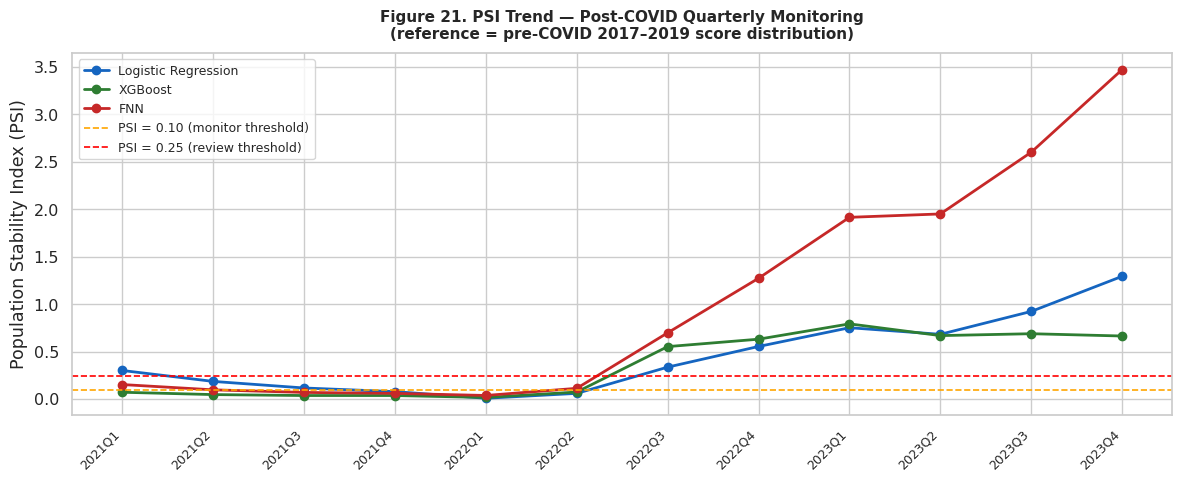

  → Figure 21 saved: /content/drive/MyDrive/capstone/reports/figures/fig21_psi_trend.png


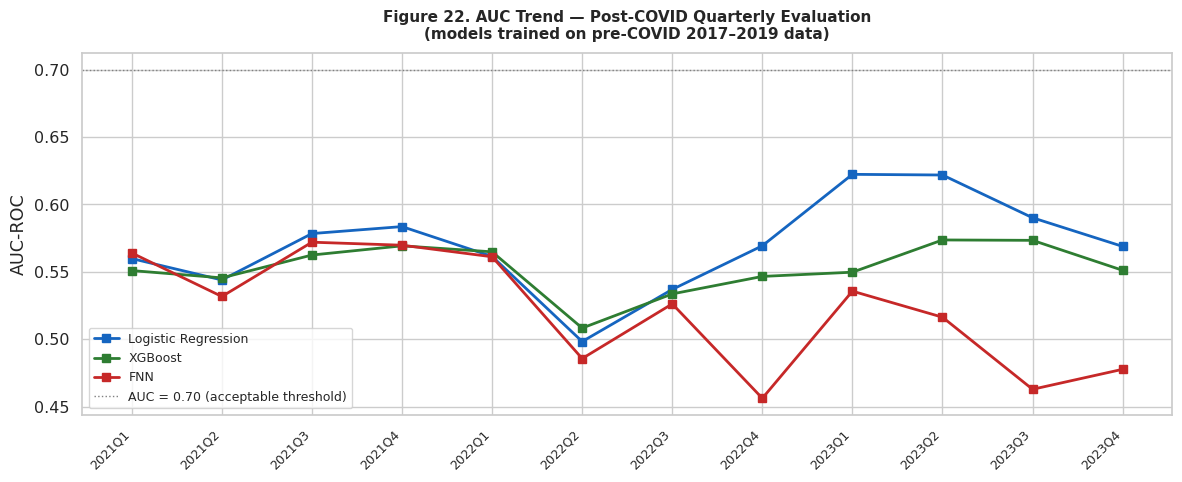

  → Figure 22 saved: /content/drive/MyDrive/capstone/reports/figures/fig22_auc_trend.png


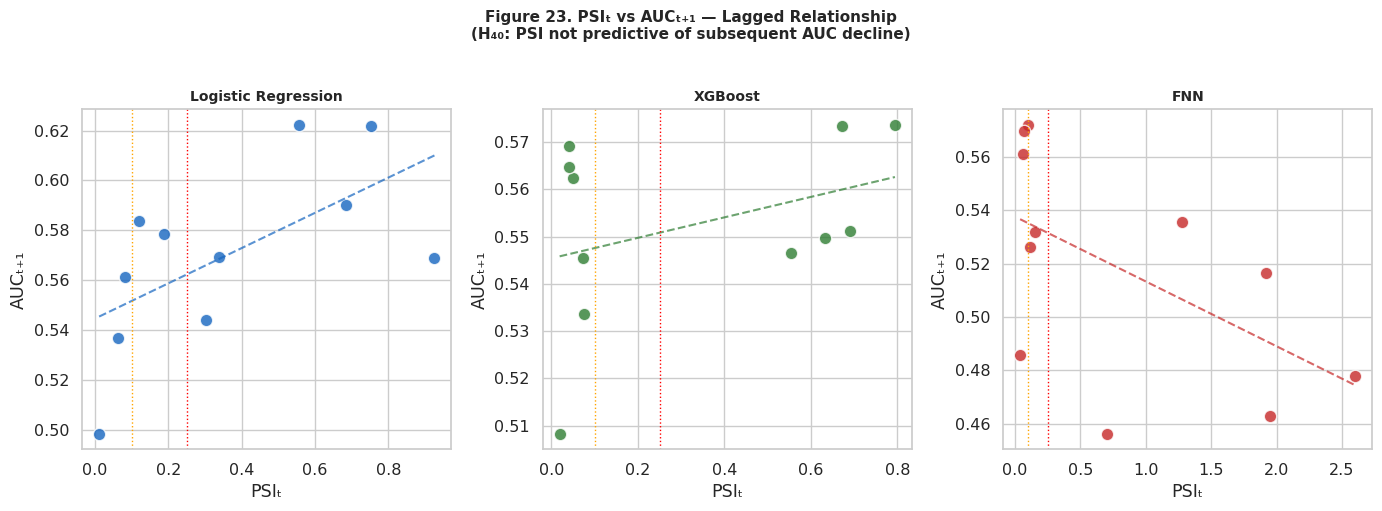

  → Figure 23 saved: /content/drive/MyDrive/capstone/reports/figures/fig23_psi_vs_auc_scatter.png


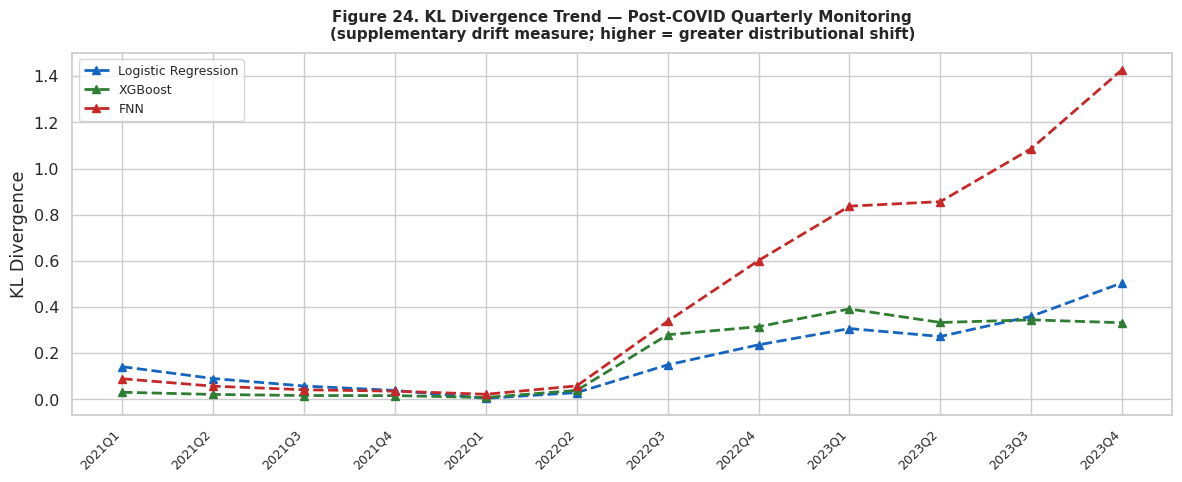

  → Figure 24 saved: /content/drive/MyDrive/capstone/reports/figures/fig24_kl_divergence.png
  ✓ Cell 6 complete


In [9]:
"""
CELL 6 — Visualisations: PSI, AUC, KL Divergence, and Lagged Relationships
==========================================================================

Purpose
-------
Generate all visual diagnostics for post‑COVID model drift analysis:

Figures
-------
Figure 21 — PSI trend over time (per model)
    • Shows quarterly PSI values for LR, XGB, FNN
    • Includes SR 11‑7 thresholds at 0.10 and 0.25

Figure 22 — AUC trend over time (per model)
    • Shows quarterly AUC values for LR, XGB, FNN
    • Includes AUC=0.70 reference line

Figure 23 — PSIₜ vs AUCₜ₊₁ scatter (lagged)
    • Visualizes whether PSI predicts next‑quarter AUC
    • Includes linear trend line when ≥3 valid points

Figure 24 — KL divergence trend over time
    • Supplementary drift measure (distributional shift)

Inputs
------
df_results : pandas.DataFrame
    Quarterly PSI, AUC, and KL metrics from Cell 4.

FIG_DIR : str
    Directory where figures are saved.

Outputs
-------
PNG files saved to FIG_DIR:
    fig21_psi_trend.png
    fig22_auc_trend.png
    fig23_psi_vs_auc_scatter.png
    fig24_kl_divergence.png

Notes
-----
- All plots use consistent color coding across models.
- xtick labels rotated for readability.
- Tight layout ensures publication‑ready formatting.
"""

# =============================================================================
# CELL 6 · PSI and AUC drift visualisations
# =============================================================================
section("CELL 6 · PSI and AUC drift visualisations")

quarters_plot = df_results["quarter"].tolist()
x_pos         = np.arange(len(quarters_plot))


# -----------------------------------------------------------------------------
# Figure 21 — PSI over time by model
# -----------------------------------------------------------------------------
"""
Figure 21
---------
Plot quarterly PSI values for LR, XGB, and FNN.

Includes:
- SR 11‑7 thresholds at PSI=0.10 and PSI=0.25
- Consistent color palette
- Publication‑ready formatting
"""
fig, ax = plt.subplots(figsize=(12, 5))
for col, label, color in [
    ("lr_psi",  "Logistic Regression", "#1565C0"),
    ("xgb_psi", "XGBoost",             "#2E7D32"),
    ("fnn_psi", "FNN",                 "#C62828"),
]:
    ax.plot(x_pos, df_results[col], marker="o",
            color=color, label=label, linewidth=2)

ax.axhline(0.10, color="orange", linestyle="--", lw=1.2,
           label="PSI = 0.10 (monitor threshold)")
ax.axhline(0.25, color="red",    linestyle="--", lw=1.2,
           label="PSI = 0.25 (review threshold)")
ax.set_xticks(x_pos)
ax.set_xticklabels(quarters_plot, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Population Stability Index (PSI)")
ax.set_title(
    "Figure 21. PSI Trend — Post-COVID Quarterly Monitoring\n"
    "(reference = pre-COVID 2017–2019 score distribution)",
    fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig21_psi_trend.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 21 saved: {FIG_DIR}/fig21_psi_trend.png")


# -----------------------------------------------------------------------------
# Figure 22 — AUC over time by model
# -----------------------------------------------------------------------------
"""
Figure 22
---------
Plot quarterly AUC values for LR, XGB, and FNN.

Includes:
- AUC=0.70 reference line (common acceptability threshold)
- Consistent color palette
"""
fig, ax = plt.subplots(figsize=(12, 5))
for col, label, color in [
    ("lr_auc",  "Logistic Regression", "#1565C0"),
    ("xgb_auc", "XGBoost",             "#2E7D32"),
    ("fnn_auc", "FNN",                 "#C62828"),
]:
    ax.plot(x_pos, df_results[col], marker="s",
            color=color, label=label, linewidth=2)

ax.axhline(0.70, color="gray", linestyle=":", lw=1,
           label="AUC = 0.70 (acceptable threshold)")
ax.set_xticks(x_pos)
ax.set_xticklabels(quarters_plot, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("AUC-ROC")
ax.set_title(
    "Figure 22. AUC Trend — Post-COVID Quarterly Evaluation\n"
    "(models trained on pre-COVID 2017–2019 data)",
    fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig22_auc_trend.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 22 saved: {FIG_DIR}/fig22_auc_trend.png")


# -----------------------------------------------------------------------------
# Figure 23 — PSI vs AUC scatter (lagged)
# -----------------------------------------------------------------------------
"""
Figure 23
---------
Scatter plot of PSIₜ vs AUCₜ₊₁ for each model.

Purpose:
- Visualize whether PSI is a leading indicator of AUC decline.
- Overlay linear trend line when ≥3 valid points.
- Include PSI thresholds at 0.10 and 0.25.
"""
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_configs = [
    ("Logistic Regression", "lr_psi",  "lr_auc",  "#1565C0"),
    ("XGBoost",             "xgb_psi", "xgb_auc", "#2E7D32"),
    ("FNN",                 "fnn_psi", "fnn_auc", "#C62828"),
]
for ax, (name, psi_col, auc_col, color) in zip(axes, model_configs):
    psi_lag = df_results[psi_col].values[:-1]
    auc_nxt = df_results[auc_col].values[1:]
    valid   = ~(np.isnan(psi_lag) | np.isnan(auc_nxt))

    ax.scatter(psi_lag[valid], auc_nxt[valid],
               color=color, s=80, alpha=0.8, edgecolors="white")

    if valid.sum() >= 3:
        m, b = np.polyfit(psi_lag[valid], auc_nxt[valid], 1)
        x_line = np.linspace(psi_lag[valid].min(), psi_lag[valid].max(), 50)
        ax.plot(x_line, m * x_line + b, color=color,
                linestyle="--", lw=1.5, alpha=0.7)

    ax.axvline(0.10, color="orange", linestyle=":", lw=1)
    ax.axvline(0.25, color="red",    linestyle=":", lw=1)
    ax.set_xlabel("PSIₜ")
    ax.set_ylabel("AUCₜ₊₁")
    ax.set_title(name, fontsize=10, fontweight="bold")

fig.suptitle(
    "Figure 23. PSIₜ vs AUCₜ₊₁ — Lagged Relationship\n"
    "(H₄₀: PSI not predictive of subsequent AUC decline)",
    fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig23_psi_vs_auc_scatter.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 23 saved: {FIG_DIR}/fig23_psi_vs_auc_scatter.png")


# -----------------------------------------------------------------------------
# Figure 24 — KL divergence over time
# -----------------------------------------------------------------------------
"""
Figure 24
---------
Plot quarterly KL divergence values for LR, XGB, and FNN.

Purpose:
- Provide supplementary drift measure.
- Higher KL indicates greater distributional shift.
"""
fig, ax = plt.subplots(figsize=(12, 5))
for col, label, color in [
    ("lr_kl",  "Logistic Regression", "#1565C0"),
    ("xgb_kl", "XGBoost",             "#2E7D32"),
    ("fnn_kl", "FNN",                 "#C62828"),
]:
    ax.plot(x_pos, df_results[col], marker="^",
            color=color, label=label, linewidth=2, linestyle="--")

ax.set_xticks(x_pos)
ax.set_xticklabels(quarters_plot, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("KL Divergence")
ax.set_title(
    "Figure 24. KL Divergence Trend — Post-COVID Quarterly Monitoring\n"
    "(supplementary drift measure; higher = greater distributional shift)",
    fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig24_kl_divergence.png",
            dpi=150, bbox_inches="tight")
plt.show(); plt.close()
log(f"  → Figure 24 saved: {FIG_DIR}/fig24_kl_divergence.png")


log("  ✓ Cell 6 complete")


In [10]:
"""
CELL 7 — Save RQ4 Metrics for MRRS Notebook
===========================================

Purpose
-------
Compile and persist all RQ4 drift‑related metrics for downstream
MRRS (Model Risk Rating System) consumption.

This cell:
1. Aggregates:
    • Quarterly PSI, AUC, KL metrics (from Cell 4)
    • Time‑series regression results (from Cell 5)
    • Summary statistics per model (mean PSI, max PSI, AUC decline, etc.)
2. Computes MRRS stability score:
       stability = max(0, 1 − mean_psi / 0.25)
   Normalized so:
       • 1.0 = perfectly stable (PSI=0)
       • 0.0 = PSI at or above review threshold (0.25)
3. Saves:
    • rq4_metrics.json — full structured output
    • table4_quarterly_psi_auc.csv — quarterly table for reporting

Inputs
------
df_results : pandas.DataFrame
    Quarterly PSI, AUC, KL metrics.

ts_results : dict
    Time‑series regression outputs from Cell 5.

SYNTHETIC_MODE : bool
PRE_COVID_QUARTERS : list[str]
POST_COVID_QUARTERS : list[str]

REPORT_DIR : str
    Directory where JSON and CSV files are written.

Outputs
-------
rq4_metrics.json
    Full RQ4 metrics dictionary.

table4_quarterly_psi_auc.csv
    Quarterly PSI/AUC table for interim reporting.

Notes
-----
- JSON uses default=str to serialize NumPy types.
- MRRS stability score is bounded [0, 1].
"""

# =============================================================================
# CELL 7 · Save RQ4 metrics for MRRS notebook
# =============================================================================
section("CELL 7 · Save RQ4 metrics for MRRS notebook")

# -----------------------------------------------------------------------------
# Assemble top-level RQ4 metrics dictionary
# -----------------------------------------------------------------------------
"""
Collect global metadata, quarterly results, and regression outputs.
"""
rq4_metrics = {
    "synthetic_mode": SYNTHETIC_MODE,
    "pre_covid_quarters": PRE_COVID_QUARTERS,
    "post_covid_quarters": POST_COVID_QUARTERS,
    "quarterly_results": df_results.to_dict(orient="records"),
    "time_series_regression": ts_results,
}

# -----------------------------------------------------------------------------
# Summary statistics per model
# -----------------------------------------------------------------------------
"""
For each model (LR, XGB, FNN), compute:
- mean PSI
- max PSI
- number of quarters requiring review (PSI > 0.25)
- number of quarters requiring monitoring (0.10 ≤ PSI ≤ 0.25)
- mean post‑COVID AUC
- minimum post‑COVID AUC
- AUC decline from first to last quarter
"""
for model_key, psi_col, auc_col in [
    ("lr",  "lr_psi",  "lr_auc"),
    ("xgb", "xgb_psi", "xgb_auc"),
    ("fnn", "fnn_psi", "fnn_auc"),
]:
    psi_vals = df_results[psi_col].dropna()
    auc_vals = df_results[auc_col].dropna()

    rq4_metrics[model_key] = {
        "mean_psi":    float(psi_vals.mean()) if len(psi_vals) > 0 else None,
        "max_psi":     float(psi_vals.max())  if len(psi_vals) > 0 else None,
        "n_quarters_review": int((psi_vals > 0.25).sum()),
        "n_quarters_monitor": int(((psi_vals >= 0.10) &
                                    (psi_vals <= 0.25)).sum()),
        "mean_post_auc": float(auc_vals.mean()) if len(auc_vals) > 0 else None,
        "min_post_auc":  float(auc_vals.min())  if len(auc_vals) > 0 else None,
        "auc_decline":   float(auc_vals.iloc[0] - auc_vals.iloc[-1])
                         if len(auc_vals) >= 2 else None,
    }

# -----------------------------------------------------------------------------
# MRRS stability score
# -----------------------------------------------------------------------------
"""
Compute MRRS stability score:

    stability = max(0, 1 − mean_psi / 0.25)

Interpretation:
- PSI = 0.00 → stability = 1.00 (perfect)
- PSI = 0.25 → stability = 0.00 (review threshold)
- PSI > 0.25 → stability = 0.00 (capped)
"""
for model_key in ["lr", "xgb", "fnn"]:
    if rq4_metrics[model_key]["mean_psi"] is not None:
        rq4_metrics[model_key]["mrrs_stability_score"] = float(
            max(0, 1 - rq4_metrics[model_key]["mean_psi"] / 0.25)
        )

# -----------------------------------------------------------------------------
# Save JSON output
# -----------------------------------------------------------------------------
"""
Write full RQ4 metrics dictionary to JSON for MRRS notebook.
"""
RQ4_PATH = f"{REPORT_DIR}/rq4_metrics.json"
with open(RQ4_PATH, "w") as f:
    json.dump(rq4_metrics, f, indent=2, default=str)
log(f"  → RQ4 metrics saved: {RQ4_PATH}")

# -----------------------------------------------------------------------------
# Save quarterly PSI/AUC table as CSV
# -----------------------------------------------------------------------------
"""
Write quarterly PSI/AUC table for interim reporting.
"""
RESULTS_CSV = f"{REPORT_DIR}/table4_quarterly_psi_auc.csv"
df_results.to_csv(RESULTS_CSV, index=False)
log(f"  → Quarterly PSI/AUC table saved: {RESULTS_CSV}")

log("  ✓ Cell 7 complete")



  CELL 7 · Save RQ4 metrics for MRRS notebook
  → RQ4 metrics saved: /content/drive/MyDrive/capstone/reports/rq4_metrics.json
  → Quarterly PSI/AUC table saved: /content/drive/MyDrive/capstone/reports/table4_quarterly_psi_auc.csv
  ✓ Cell 7 complete


In [11]:
# CELL 8 · Readiness verdict
# =============================================================================
section("CELL 8 · RQ4 readiness verdict")

checks = []

def check(label, condition, note=""):
    status = "✓" if condition else "✗"
    line   = f"  {status}  {label}"
    if note: line += f"\n       {note}"
    log(line)
    checks.append(condition)

log()
check("Fannie Mae data loaded (real or synthetic)",
      N_PRE > 0 and N_POST > 0,
      f"Pre-COVID: {N_PRE:,} rows  Post-COVID: {N_POST:,} rows")
check("Pre-COVID training set available",
      N_PRE > 0)
check("Post-COVID evaluation set available",
      N_POST > 0)
check("All three models trained on pre-COVID data",
      all(m is not None for m in [fm_lr, fm_xgb, fm_fnn]))
check("Quarterly PSI computed for all post-COVID quarters",
      len(df_results) > 0)
check("KL divergence computed",
      "lr_kl" in df_results.columns)
check("Time-series regression run for H₄₀",
      len(ts_results) > 0)
check("Figures 21–24 saved",
      all(os.path.exists(f"{FIG_DIR}/{f}") for f in [
          "fig21_psi_trend.png", "fig22_auc_trend.png",
          "fig23_psi_vs_auc_scatter.png", "fig24_kl_divergence.png",
      ]))
check("RQ4 metrics JSON saved for MRRS notebook",
      os.path.exists(RQ4_PATH))

if SYNTHETIC_MODE:
    log()
    log("  ⚠  SYNTHETIC MODE — results are for pipeline validation only.")
    log("     Replace with real Fannie Mae data before final submission.")
    log("     Upload quarterly files to:")
    log(f"     {FM_RAW_DIR}/")

n_pass = sum(checks)
log()
log(f"  Result: {n_pass}/{len(checks)} checks passed  "
    + ("✓  Ready to proceed to notebook 06"
       if n_pass == len(checks)
       else "✗  Review failures above"))
log()
log("  Next step: notebook 06_rq5_mrrs_scoring.ipynb")

with open(REPORT_FILE, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
log(f"\n  Full report written to: {REPORT_FILE}")



  CELL 8 · RQ4 readiness verdict

  ✓  Fannie Mae data loaded (real or synthetic)
       Pre-COVID: 5,994,254 rows  Post-COVID: 7,765,284 rows
  ✓  Pre-COVID training set available
  ✓  Post-COVID evaluation set available
  ✓  All three models trained on pre-COVID data
  ✓  Quarterly PSI computed for all post-COVID quarters
  ✓  KL divergence computed
  ✓  Time-series regression run for H₄₀
  ✓  Figures 21–24 saved
  ✓  RQ4 metrics JSON saved for MRRS notebook

  Result: 9/9 checks passed  ✓  Ready to proceed to notebook 06

  Next step: notebook 06_rq5_mrrs_scoring.ipynb

  Full report written to: /content/drive/MyDrive/capstone/reports/rq4_psi_report.txt
